In [1]:
import sys
from datetime import datetime, timedelta

import xarray as xr
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib
import numpy.ma as ma
import matplotlib.ticker as ticker
from scipy import stats
import os 
os.listdir("/bettik/PROJECTS/pr-regional-climate/santolam/MARout_post/GRq/spin2/work")

import matplotlib.colors as mcolors # Import les palettes de couleurs
import cartopy.crs as ccrs # Permet d'utiliser des projections de cartes
import cartopy.feature as cfeature # Permet d'ajouter d'autres éléments à la carte
import matplotlib.patches as patches # Permet de tracer des rectangles dans mon cas


In [2]:
k = 15 # Pixels à retirer aux bords du domaine (éviter effet de bord)

In [3]:
# MAR topography (pas la même correction que Xavier applique, car non nécessaire ici)

GridPath='/home/amoryc/'## Plot de la Temperature de surface de la grille correspondant au glacier Mera
Domain_grM='NST.2000.01.01.00.GRq.nc'

ds_grM= xr.open_dataset(GridPath+Domain_grM) # ds pour DataSet
#print(ds_grM)

ds_lon = ds_grM.LON[k:-k, k:-k] # Longitude
ds_lat = ds_grM.LAT[k:-k, k:-k] # Latitude
ds_SH  = ds_grM.SH[k:-k, k:-k] # Topographie en m
ds_ICE = ds_grM.ICE[k:-k, k:-k] # Pourcentage de glace par maille

# Coordonnées exactes du Peak Mera
merap_lat = 27.70984
merap_lon = 86.868662

# Coordonnées Everest
everest_lat = 27.9879017
everest_lon = 86.9253141

# Carte du pourcentage de glace par point de grille

In [4]:
ice_level = 30 # Seuil à partir duquel on considère qu'on observe de la glace

clevs = np.arange(0, 110, 10) # Echelle de couleur de 0 à 100% tous les 10%
cmap = plt.get_cmap("Blues_r") # Palette de couleur bleu (reverse) pour voir le % de glace par grille
norm_blue = mcolors.BoundaryNorm(boundaries=clevs, ncolors=cmap.N) 

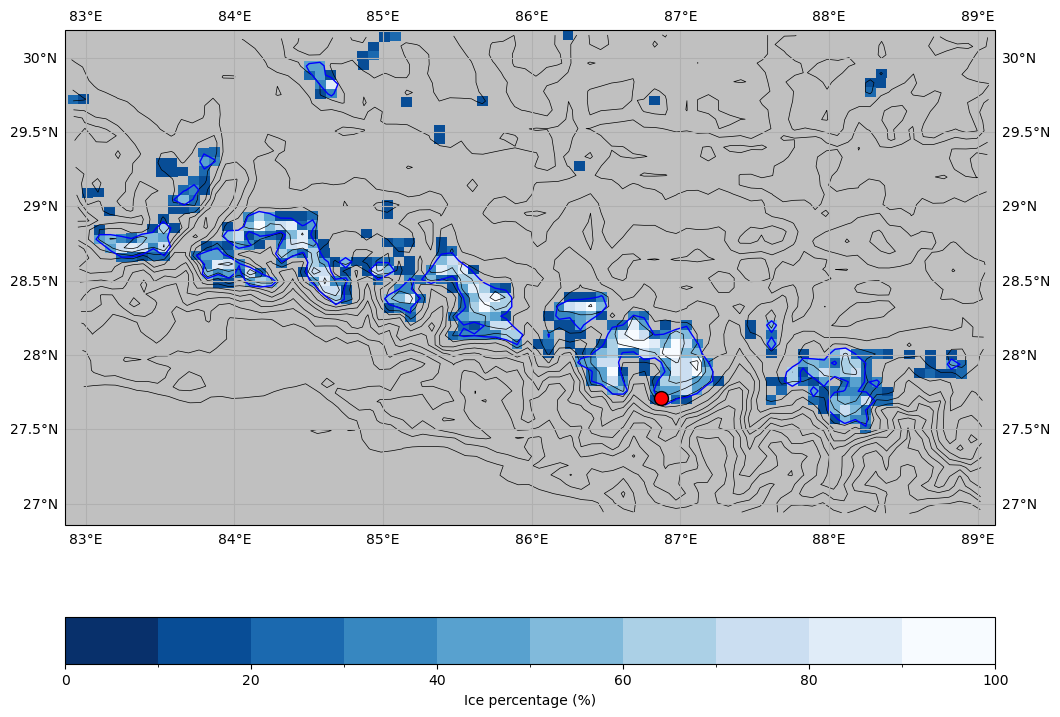

In [5]:
fig, ax = plt.subplots(figsize=(12,12),subplot_kw={'projection': ccrs.PlateCarree()}) # Utilisation de la projection plate carré

ax.set_facecolor('silver') # Fond de l'image en gris 
ICE_mask = np.ma.masked_where(ds_ICE ==0, ds_ICE) # Créer un mask sur les valeurs de % de glace nul

#### Courbes de niveau (tous les 500m) ####
SH = ax.contour(ds_lon, ds_lat, ds_SH, 
           levels=[500,1000,1500,2000,2500,3000,3500,4000,4500,5000,5500,6000,6500,7000], # Affichage des lignes de topographie
           colors="k", linewidths=0.5,
           transform=ccrs.PlateCarree())
#ax.clabel(SH, SH.levels, inline=True, fontsize=6, fmt="%d", inline_spacing=1) # Affiche valeur sur les courbes

#### Countour glaciers ####
ax.contour(ds_lon, ds_lat, ds_ICE, 
           levels=[ice_level], # Défini les lignes de contour des glaciers (bleu) où la grille dépasse la valeur de ice_level 
           colors="b", linewidths=1,
           transform=ccrs.PlateCarree())

#### Mera Peak coord ####
ax.plot(merap_lon, merap_lat,  
        marker='o', markersize=10,
        markeredgecolor='black', markerfacecolor='red',
        transform=ccrs.PlateCarree())

#### Percentage of ice ####
im = ax.pcolormesh(ds_lon, ds_lat, ICE_mask,
                   cmap=cmap, norm=norm_blue, # Affiche la couleur du % de glace
                   transform=ccrs.PlateCarree(),
                   shading="auto")

ax.gridlines(draw_labels=True) # Grille de lattitude et longitude
plt.colorbar(im, orientation="horizontal", pad=0.1, label="Ice percentage (%)") # Paramètres de la barre d'altitude (disposition horizontale / taille / légende)
plt.show()

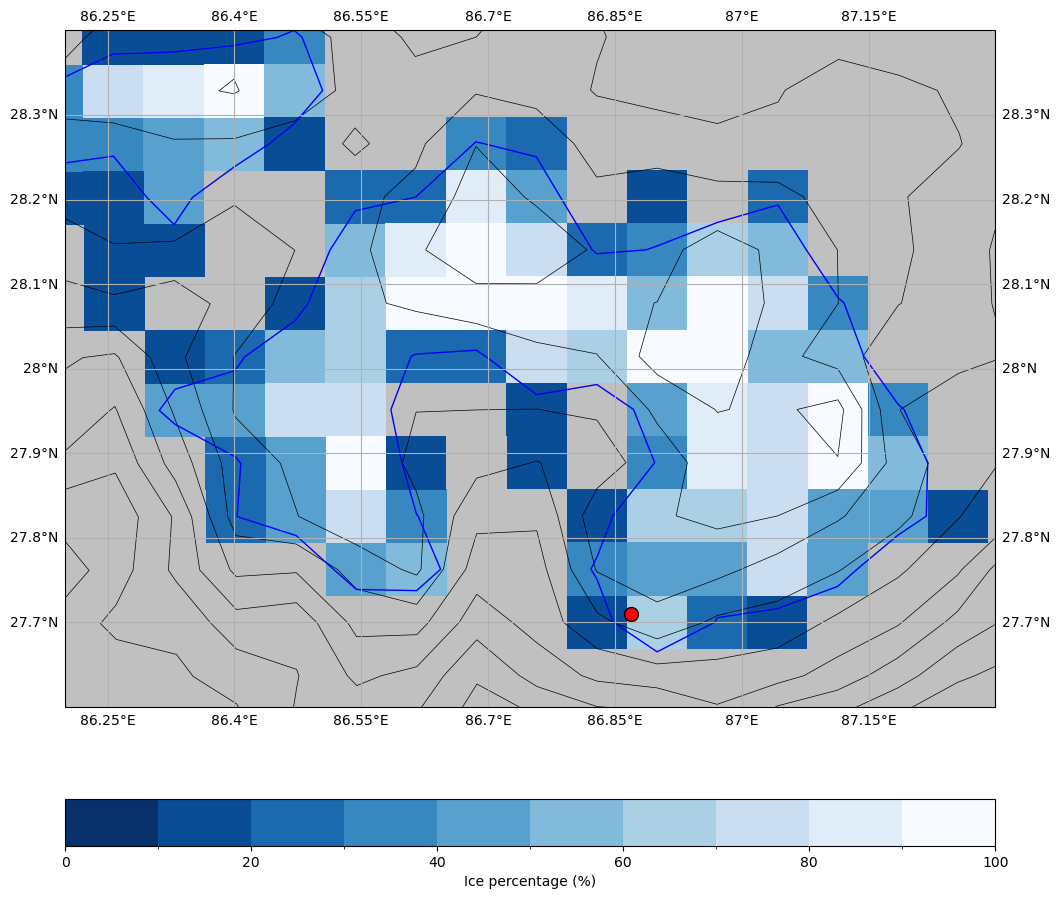

In [6]:
fig, ax = plt.subplots(figsize=(12,12),subplot_kw={'projection': ccrs.PlateCarree()}) # Utilisation de la projection plate carré

ax.set_facecolor('silver')
#### Courbes de niveau (tous les 500m) ####
SH = ax.contour(ds_lon, ds_lat, ds_SH, 
           levels=[500,1000,1500,2000,2500,3000,3500,4000,4500,5000,5500,6000,6500,7000], # Affichage des lignes de topographie
           colors="k", linewidths=0.5,
           transform=ccrs.PlateCarree())
#ax.clabel(SH, SH.levels, inline=True, fontsize=6, fmt="%d", inline_spacing=1) # Affiche valeur sur les courbes

#### Countour glaciers ####
ax.contour(ds_lon, ds_lat, ds_ICE, 
           levels=[ice_level], # Défini les lignes de contour des glaciers (bleu) où la grille dépasse la valeur de ice_level 
           colors="b", linewidths=1,
           transform=ccrs.PlateCarree())

#### Mera Peak coord ####
ax.plot(merap_lon, merap_lat,  # Coord exact du Mera Peak
        marker='o', markersize=10,
        markeredgecolor='black', markerfacecolor='red',
        transform=ccrs.PlateCarree())

#### Percentage of ice ####
im = ax.pcolormesh(ds_lon, ds_lat, ICE_mask,
                   cmap=cmap, norm=norm_blue, # Affiche la couleur du % de glace
                   transform=ccrs.PlateCarree(),
                   shading="auto")

ax.set_extent([86.2, 87.3, 27.6, 28.4], crs=ccrs.PlateCarree()) # Défini les limites (lon, lat) du domaine observable 
#ax.set_extent([86.7, 87.1, 27.6, 27.9], crs=ccrs.PlateCarree()) # Défini les limites (lon, lat) du domaine observable zoom

ax.gridlines(draw_labels=True) # Grille de lattitude et longitude
plt.colorbar(im, orientation="horizontal", pad=0.1, label="Ice percentage (%)") # Paramètres de la barre d'altitude (disposition horizontale / taille / légende)
plt.show()

# Affichage du Sector 0 pour la variable SMB (janvier)

In [30]:
sector = 1

In [31]:
####### Data loading ######
variable = 'SMB'
DataPath = '/bettik/PROJECTS/pr-regional-climate/santolam/MARout_post/GRq/spin2/work/daily/' 
 
file_sector = variable+'_daysum_MARv3.14_ER5_spin2_GRq_2024.nc'

ds_sector = xr.open_dataset(DataPath + file_sector)

sector_SMB = ds_sector.SMB.isel(TIME=0, SECTOR=sector).load()   # SECTOR de MAR ".sel" selectionne la vraie valeur de sector (1 ou 2). ".isel" selectionne l'indice (0 ou 1)
sector_SMB = sector_SMB.isel(Y=slice(k, -k), X=slice(k, -k))

# Permet d'afficher l'echelles de valeur en couleur avec séparateurs distincts mais dépendant des valeurs 
data = sector_SMB.values  
n_classes = 10
cmap = plt.get_cmap("Reds", n_classes)
norm_red = mcolors.BoundaryNorm(np.linspace(data.min(), data.max(), n_classes+1), cmap.N)

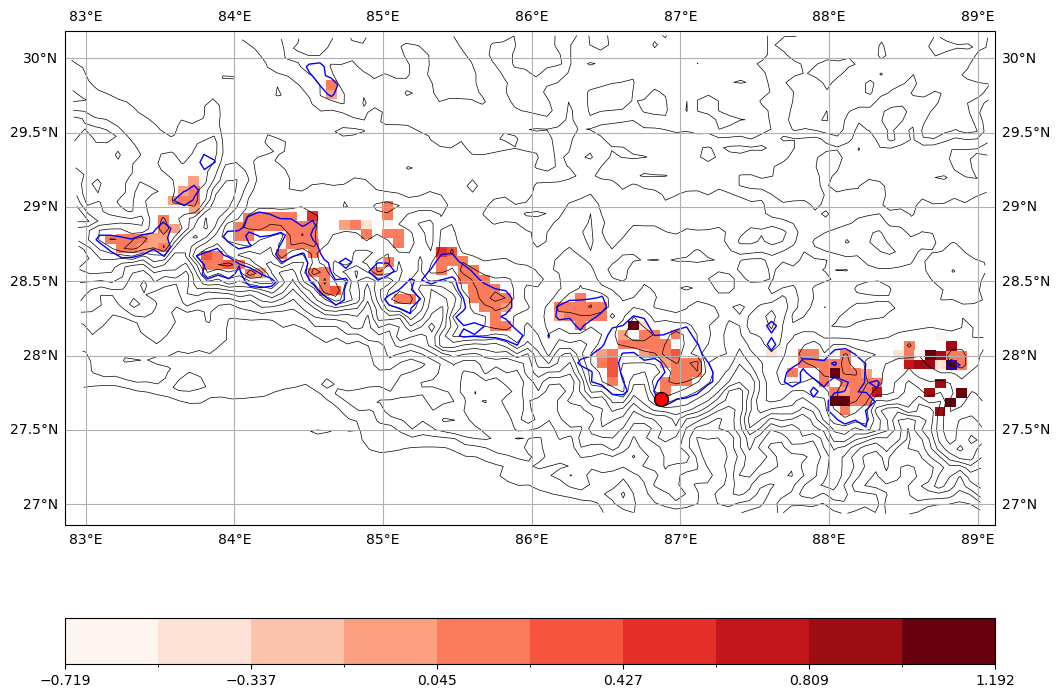

In [32]:
fig, ax = plt.subplots(figsize=(12,12),subplot_kw={'projection': ccrs.PlateCarree()}) # Utilisation de la projection plate carré

# Le mask indique que si le SMB est = 0 alors on ne prend pas en compte ces valeurs dans l'affichage 
#(permet d'avoir en blanc les cases où on a pas de surface avec de la glace)
sector_mask = np.ma.masked_where(sector_SMB ==0, sector_SMB) 

#### SECTOR ####
im = ax.pcolormesh(ds_lon, ds_lat, sector_mask,
              cmap=cmap, norm=norm_red,
              transform=ccrs.PlateCarree(),
              shading="auto")

#### Courbes de niveau (tous les 500m) ####
SH = ax.contour(ds_lon, ds_lat, ds_SH, 
           levels=[500,1000,1500,2000,2500,3000,3500,4000,4500,5000,5500,6000,6500,7000], # Affichage des lignes de topographie
           colors="k", linewidths=0.5,
           transform=ccrs.PlateCarree())
#ax.clabel(SH, SH.levels, inline=True, fontsize=6, fmt="%d", inline_spacing=1) # Affiche valeur sur les courbes

#### Countour glaciers ####
ax.contour(ds_lon, ds_lat, ds_ICE, 
           levels=[ice_level], # Défini les lignes de contour des glaciers (bleu) où la grille dépasse la valeur de ice_level 
           colors="b", linewidths=1,
           transform=ccrs.PlateCarree())

#### Mera Peak coord ####
ax.plot(merap_lon, merap_lat,  
        marker='o', markersize=10,
        markeredgecolor='black', markerfacecolor='red',
        transform=ccrs.PlateCarree())

plt.colorbar(im, orientation="horizontal", pad=0.1)

ax.gridlines(draw_labels=True) # Grille de lattitude et longitude
plt.show()

# Carte de la région du Mera 

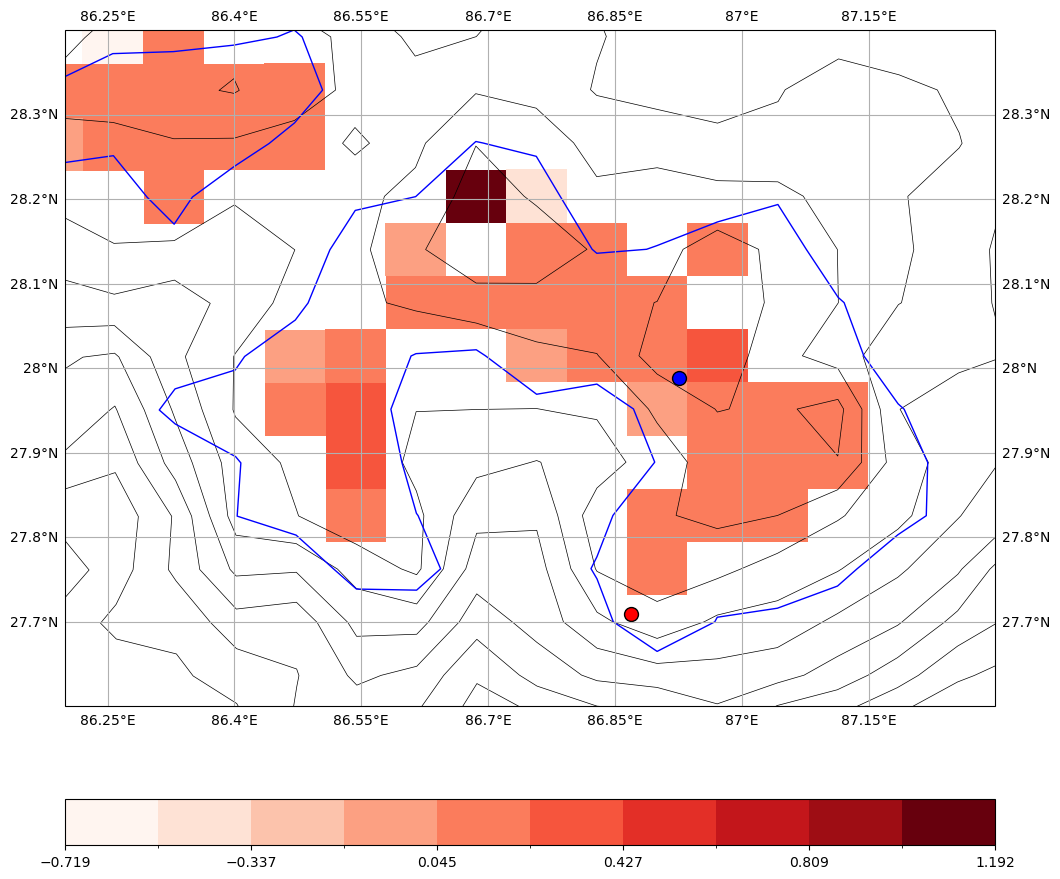

In [33]:
fig, ax = plt.subplots(figsize=(12,12),subplot_kw={'projection': ccrs.PlateCarree()}) # Utilisation de la projection plate carré

sector_mask = np.ma.masked_where(sector_SMB ==0, sector_SMB)

#### SECTOR ####
im = ax.pcolormesh(ds_lon, ds_lat, sector_mask,
              cmap=cmap,
              norm=norm_red,
              transform=ccrs.PlateCarree(),
              shading="auto")

plt.colorbar(im, orientation="horizontal", pad=0.1)

#ax.contour(ds_lon, ds_lat, sector_mask, levels=[0.5], colors="red", linewidths=2, transform=ccrs.PlateCarree())


#### Courbes de niveau (tous les 500m) ####
SH = ax.contour(ds_lon, ds_lat, ds_SH, 
           levels=[500,1000,1500,2000,2500,3000,3500,4000,4500,5000,5500,6000,6500,7000], # Affichage des lignes de topographie
           colors="k", linewidths=0.5,
           transform=ccrs.PlateCarree())
#ax.clabel(SH, SH.levels, inline=True, fontsize=6, fmt="%d", inline_spacing=1) # Affiche valeur sur les courbes

#### Countour glaciers ####
ax.contour(ds_lon, ds_lat, ds_ICE, 
           levels=[ice_level], # Défini les lignes de contour des glaciers (bleu) où la grille dépasse la valeur de ice_level 
           colors="b", linewidths=1,
           transform=ccrs.PlateCarree())

#### Mera Peak coord ####
ax.plot(merap_lon, merap_lat,  # Coord exact du Mera Peak
        marker='o', markersize=10,
        markeredgecolor='black', markerfacecolor='red',
        transform=ccrs.PlateCarree())

#### Everest coord ####
ax.plot(everest_lon, everest_lat,  # Coord exact du Mera Peak
        marker='o', markersize=10,
        markeredgecolor='black', markerfacecolor='b',
        transform=ccrs.PlateCarree())

ax.set_extent([86.2, 87.3, 27.6, 28.4], crs=ccrs.PlateCarree()) # Défini les limites (lon, lat) du domaine observable 
#ax.set_extent([86.2, 87.4, 27.3, 28.4], crs=ccrs.PlateCarree()) # Défini les limites (lon, lat) du domaine observable 
#ax.set_extent([86.7, 87.1, 27.6, 27.9], crs=ccrs.PlateCarree()) # Défini les limites (lon, lat) du domaine observable zoom

ax.gridlines(draw_labels=True) # Grille de lattitude et longitude
plt.show()

### Identification des indices X et Y de la grille correspondant au glacier Mera 
#### C'est à dire le point de grille le plus proche des coordonnées réelles

In [34]:
#### Récupération des indices de la grille pour afficher des variables uniquement sur cette grille ####

dist = np.sqrt((ds_lat - merap_lat)**2 + (ds_lon - merap_lon)**2) # Calcul des distances entre les centres des grilles et coordonnées du Mera Peak
 
# index 1D du minimum
idx_1d = dist.argmin().item() # Recherche de la distance minimale avec argmin

# conversion en indices 2D (Y,X) 
iY, iX = np.unravel_index(idx_1d, dist.shape)

print("Indice Y :", iY)
print("Indice X :", iX)
print("Latitude trouvée :", ds_lat[iY, iX].item())
print("Longitude trouvée :", ds_lon[iY, iX].item())

Indice Y : 12
Indice X : 55
Latitude trouvée : 27.69999885559082
Longitude trouvée : 86.89999389648438


# Loading and sorting OBS data glacioclim

In [35]:
yy = [f"{i:02}" for i in range(7, 26)] # Liste des années sous le format yy

nyy = len(yy)-2

##### Définitions des variables accumulations et d'ablation pour le Mera(m) et Naulek(n) (Naulak n'a pas de balise en accu)
SMB_accu_m, SH_accu_m, reg_accu_m = [], [], []
SMB_ablation_m, SH_ablation_m, reg_ablation_m = [], [], []
SMB_ablation_n, SH_ablation_n, reg_ablation_n = [], [], []

date_obs, date_ref = [], [] # Stock les intervalles entre les mesures j et j-1 pour chaque année

for j in range(nyy):
    
###### OBS_data loading and sorting ######    
    df = pd.read_excel('/home/turpinli/Mera_SMB/AnnualMB_Mera_'+yy[j]+'_'+yy[j+1]+'.xlsx', header=1) #pandas permet ici de lire les fichiers .xlsx et prenant les colonnes à partir de la 2ème ligne

    glacier_col = df.columns[df.apply(lambda col: col.astype(str).str.contains("branch", na=False)).any()][0]
    
    date_obs.append(df["Date_end"].iloc[4]) # Je pensais que le format de date qui diffère de glacioclim à MAR était un pb, mais excel est bien en format datetime et non texte donc cela fonctionne sans correction
    date_ref.append(df["Date_start"].iloc[4]) # Récupère la précédente date de mesure de SMB pour cette balise

    
    MB = df.filter(regex=r"^Mass balance \(").columns[0] # Regex recupère les données dans la colonne Mass balance, peut importe ce qui suit dans la chaine de caractères 
    df[MB] = pd.to_numeric(df[MB], errors="coerce") # Force la colonne à prendre la forme d'un nombre (car unité en haut de colonne)
    df["Altitude_end"] = pd.to_numeric(df["Altitude_end"], errors="coerce") # Coerce donne NaN si la valeur n'est pas convertible en nombre

    df = df.dropna(subset=["Altitude_end",MB]) # Supprime les NaN dans les colonnes

    df_ablation = df[df["#station"].str.match(r"^\d") | (df["#station"] == "AWS")] # Catégorise les stations qui commencent par un chiffre ou qui sont strictement AWS, en ablaion
    df_accu = df[~(df["#station"].str.match(r"^\d") | (df["#station"] == "AWS"))] # Le ~ est la condition "not" --> Tout le reste / (r"^\d" identifie les chiffres) et "|" vérifie les deux conditions 

    df_accu_m   = df_accu[df_accu[glacier_col] == "Mera branch"]
    df_ablation_m   = df_ablation[df_ablation[glacier_col] == "Mera branch"]
    df_ablation_n = df_ablation[df_ablation[glacier_col] == "Naulek branch"]
    
    ###### Accumulation ######
    x_accu_m = df_accu_m[MB]
    y_accu_m = df_accu_m["Altitude_end"]
    
    if len(x_accu_m) >= 2:
        res_accu_m = stats.linregress(x_accu_m, y_accu_m)

    SMB_accu_m.append(x_accu_m)
    SH_accu_m.append(y_accu_m)
    reg_accu_m.append(res_accu_m)

    ##### Ablation ######
    x_ablation_m = df_ablation_m[MB]
    y_ablation_m = df_ablation_m["Altitude_end"]

    x_ablation_n = df_ablation_n[MB]
    y_ablation_n = df_ablation_n["Altitude_end"]

    if len(x_ablation_m) >= 2:
        res_ablation_m = stats.linregress(x_ablation_m, y_ablation_m)

    if len(x_ablation_n) >= 2:
        res_ablation_n = stats.linregress(x_ablation_n, y_ablation_n)
        
    SMB_ablation_m.append(x_ablation_m)
    SH_ablation_m.append(y_ablation_m)
    reg_ablation_m.append(res_ablation_m)

    SMB_ablation_n.append(x_ablation_n)
    SH_ablation_n.append(y_ablation_n)
    reg_ablation_n.append(res_ablation_n)

# Loading MAR data 

## Test affichage SMB avec SECTOR=1

In [36]:
####### Data loading ######
variable = 'SMB'
DataPath = '/bettik/PROJECTS/pr-regional-climate/santolam/MARout_post/GRq/spin2/work/daily/' 

SMB_year = []

for j in range(nyy):

    ###### MAR_data loading and sorting  ######    
    file = variable+'_daysum_MARv3.14_ER5_spin2_GRq_20'+yy[j+1]+'.nc'
    ds_SMBy = xr.open_dataset(DataPath+file).SMB.isel(SECTOR=1).load() # Sector correspond à des types d'occupation des sols en % (ex: 30% de la grille occupé par de la végétation)
    ds_SMBy = ds_SMBy[:,k:-k,k:-k]
    SMB_year.append(ds_SMBy)


####### Style of map 3x3 or khumbu #####
clevs = np.arange(0, 7500, 500) # Echelle de couleur de topographie de 0 à 7500 tout les 500m d'alt
cmap = plt.get_cmap("terrain") # Palette de couleur pour les reliefs 
norm = mcolors.BoundaryNorm(boundaries=clevs, ncolors=cmap.N) # Attribut à chaque bande d'altitude une couleur de la palette "terrain"


Grid alt = 4831.3545 m


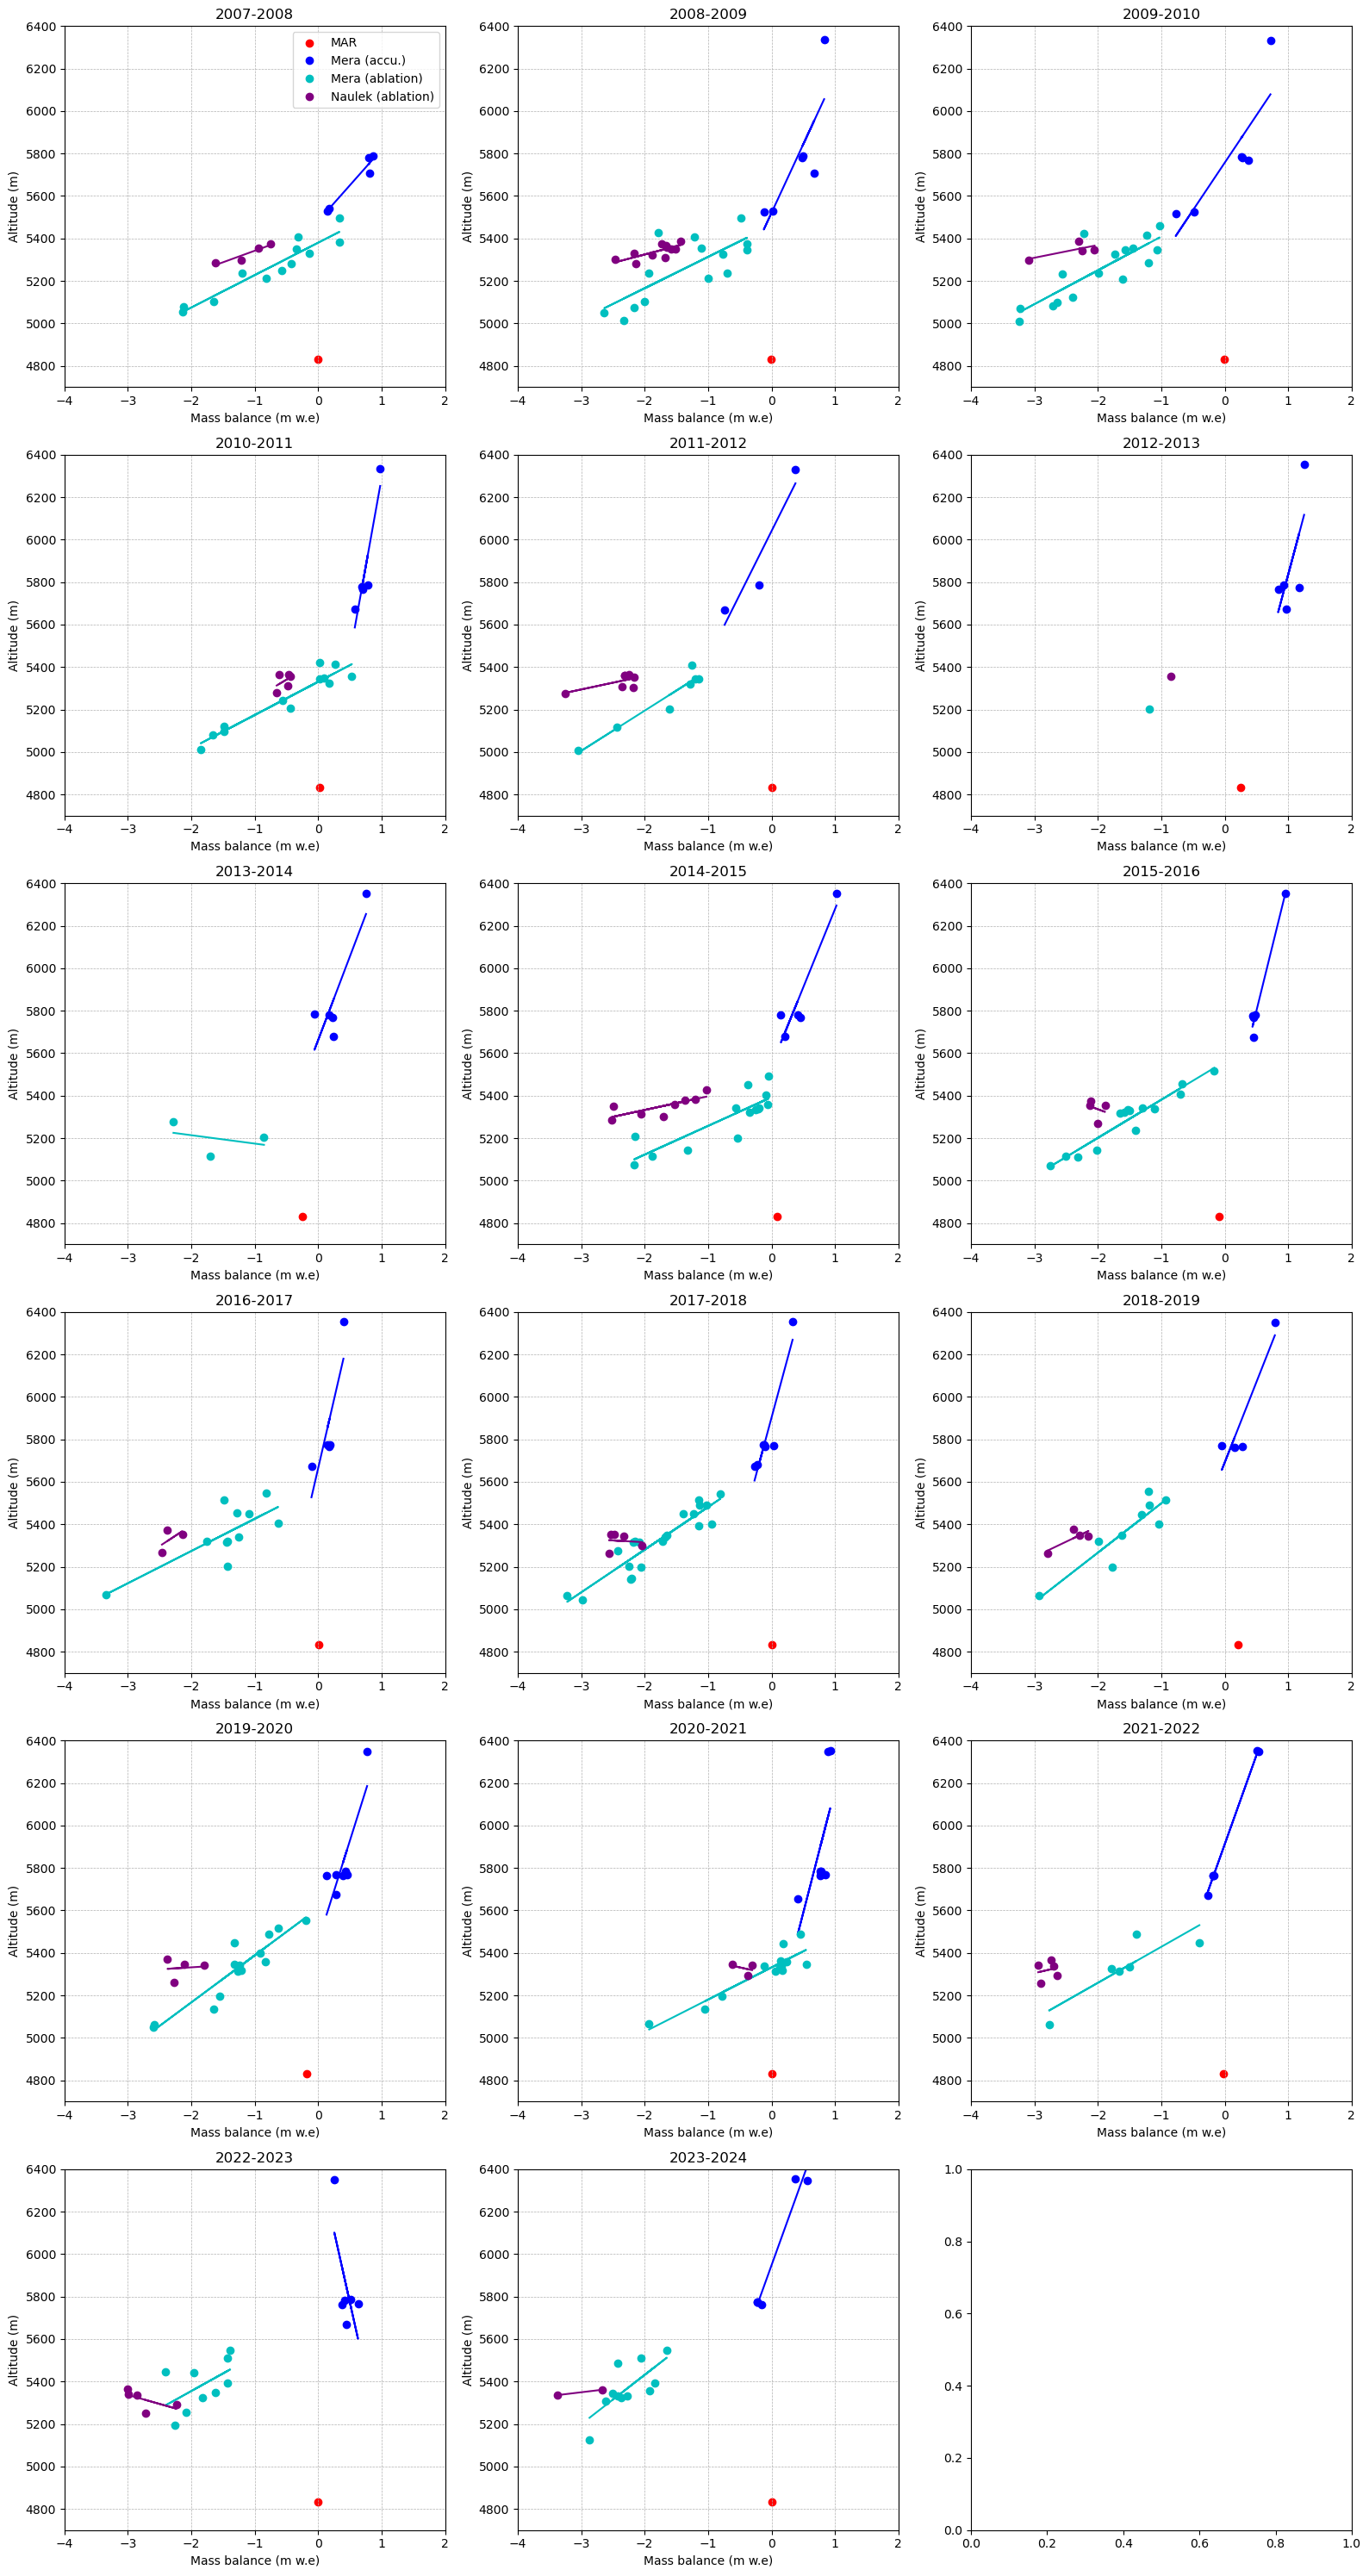

In [37]:
### Mera grid point
col = 3
line = int(np.ceil(nyy/col)) # Arrondi à l'entier supérieur le nombre de colonne à plot, et le met au format 'nombre entier'
fig, axes = plt.subplots(line,col,figsize=(16,5*line))
axes = axes.flatten() # Transforme le tableau 2D en tableau 1D (accessible avec 1 indice (j))

SMB_list_Mera = []

for j in range(nyy):
    ax = axes[j] # Remplissage subplot avec indice de la boucle
    
    ###### MAR_data loading and sorting  ######   
    SMB_day = SMB_year[j].sel(TIME=slice(date_ref[j], date_obs[j])).isel(Y=iY, X=iX) # Valeurs du SMB entre les deux dates de mesures (glacioclim)
    SMB_sum = SMB_day.sum(dim='TIME')/1000 # Somme l'entièreté de ces valeurs sur la période, et rapporte les millimètres en mètres
    SMB_MAR = SMB_sum.values
    SMB_list_Mera.append(SMB_MAR)
    #print('SMB_MAR'+yy[j]+'-'+yy[j+1]+' =', SMB_MAR, 'm w.e/yr')
    #print('Date_MAR:', ds_SMBy.sel(TIME=date_obs).TIME.values) # Affiche la date dans le fichier

    SH_MAR = ds_SH.isel(y=iY, x=iX) # Altitude de la grille de MAR au Peak Mera (coord iY,iX)
    #print('Grid alt =', SH_MAR.values, 'm')
    
    ax.scatter(SMB_MAR, SH_MAR, color="r", label="MAR") # Affiche le point de MAR correspondant à la date des obs

    ###### Plot OBSERVATIONS ######
    ###### Accumulation
    ax.plot(SMB_accu_m[j], SH_accu_m[j], linestyle="", marker="o", color='b', label='Mera (accu.)') # Mera accu
    ax.plot(SMB_accu_m[j], reg_accu_m[j].intercept + reg_accu_m[j].slope * SMB_accu_m[j], 'b') # Mera accu regression lineaire

    ###### Ablation
    ax.plot(SMB_ablation_m[j], SH_ablation_m[j], linestyle="", marker="o", color='c', label='Mera (ablation)') # Mera ablation
    ax.plot(SMB_ablation_m[j], reg_ablation_m[j].intercept + reg_ablation_m[j].slope * SMB_ablation_m[j], 'c') # Mera ablation regression
    ax.plot(SMB_ablation_n[j], SH_ablation_n[j], linestyle="", marker="o", color='purple', label='Naulek (ablation)') # Naulek ablation
    ax.plot(SMB_ablation_n[j], reg_ablation_n[j].intercept + reg_ablation_n[j].slope * SMB_ablation_n[j], 'purple') # Naulek ablation regression

    ###### Graphic features ######
    ax.set_title(f"20{yy[j]}-20{yy[j+1]}")
    ax.set_xlabel("Mass balance (m w.e)")
    ax.set_ylabel("Altitude (m)")
    ax.set_xlim(-4, 2)
    ax.set_ylim(4700, 6400)
    ax.grid(linestyle = '--', linewidth = 0.5)
    
    if j == 0: # Affiche la légende pour la première figure
        ax.legend()
print('Grid alt =', SH_MAR.values, 'm')
plt.tight_layout()

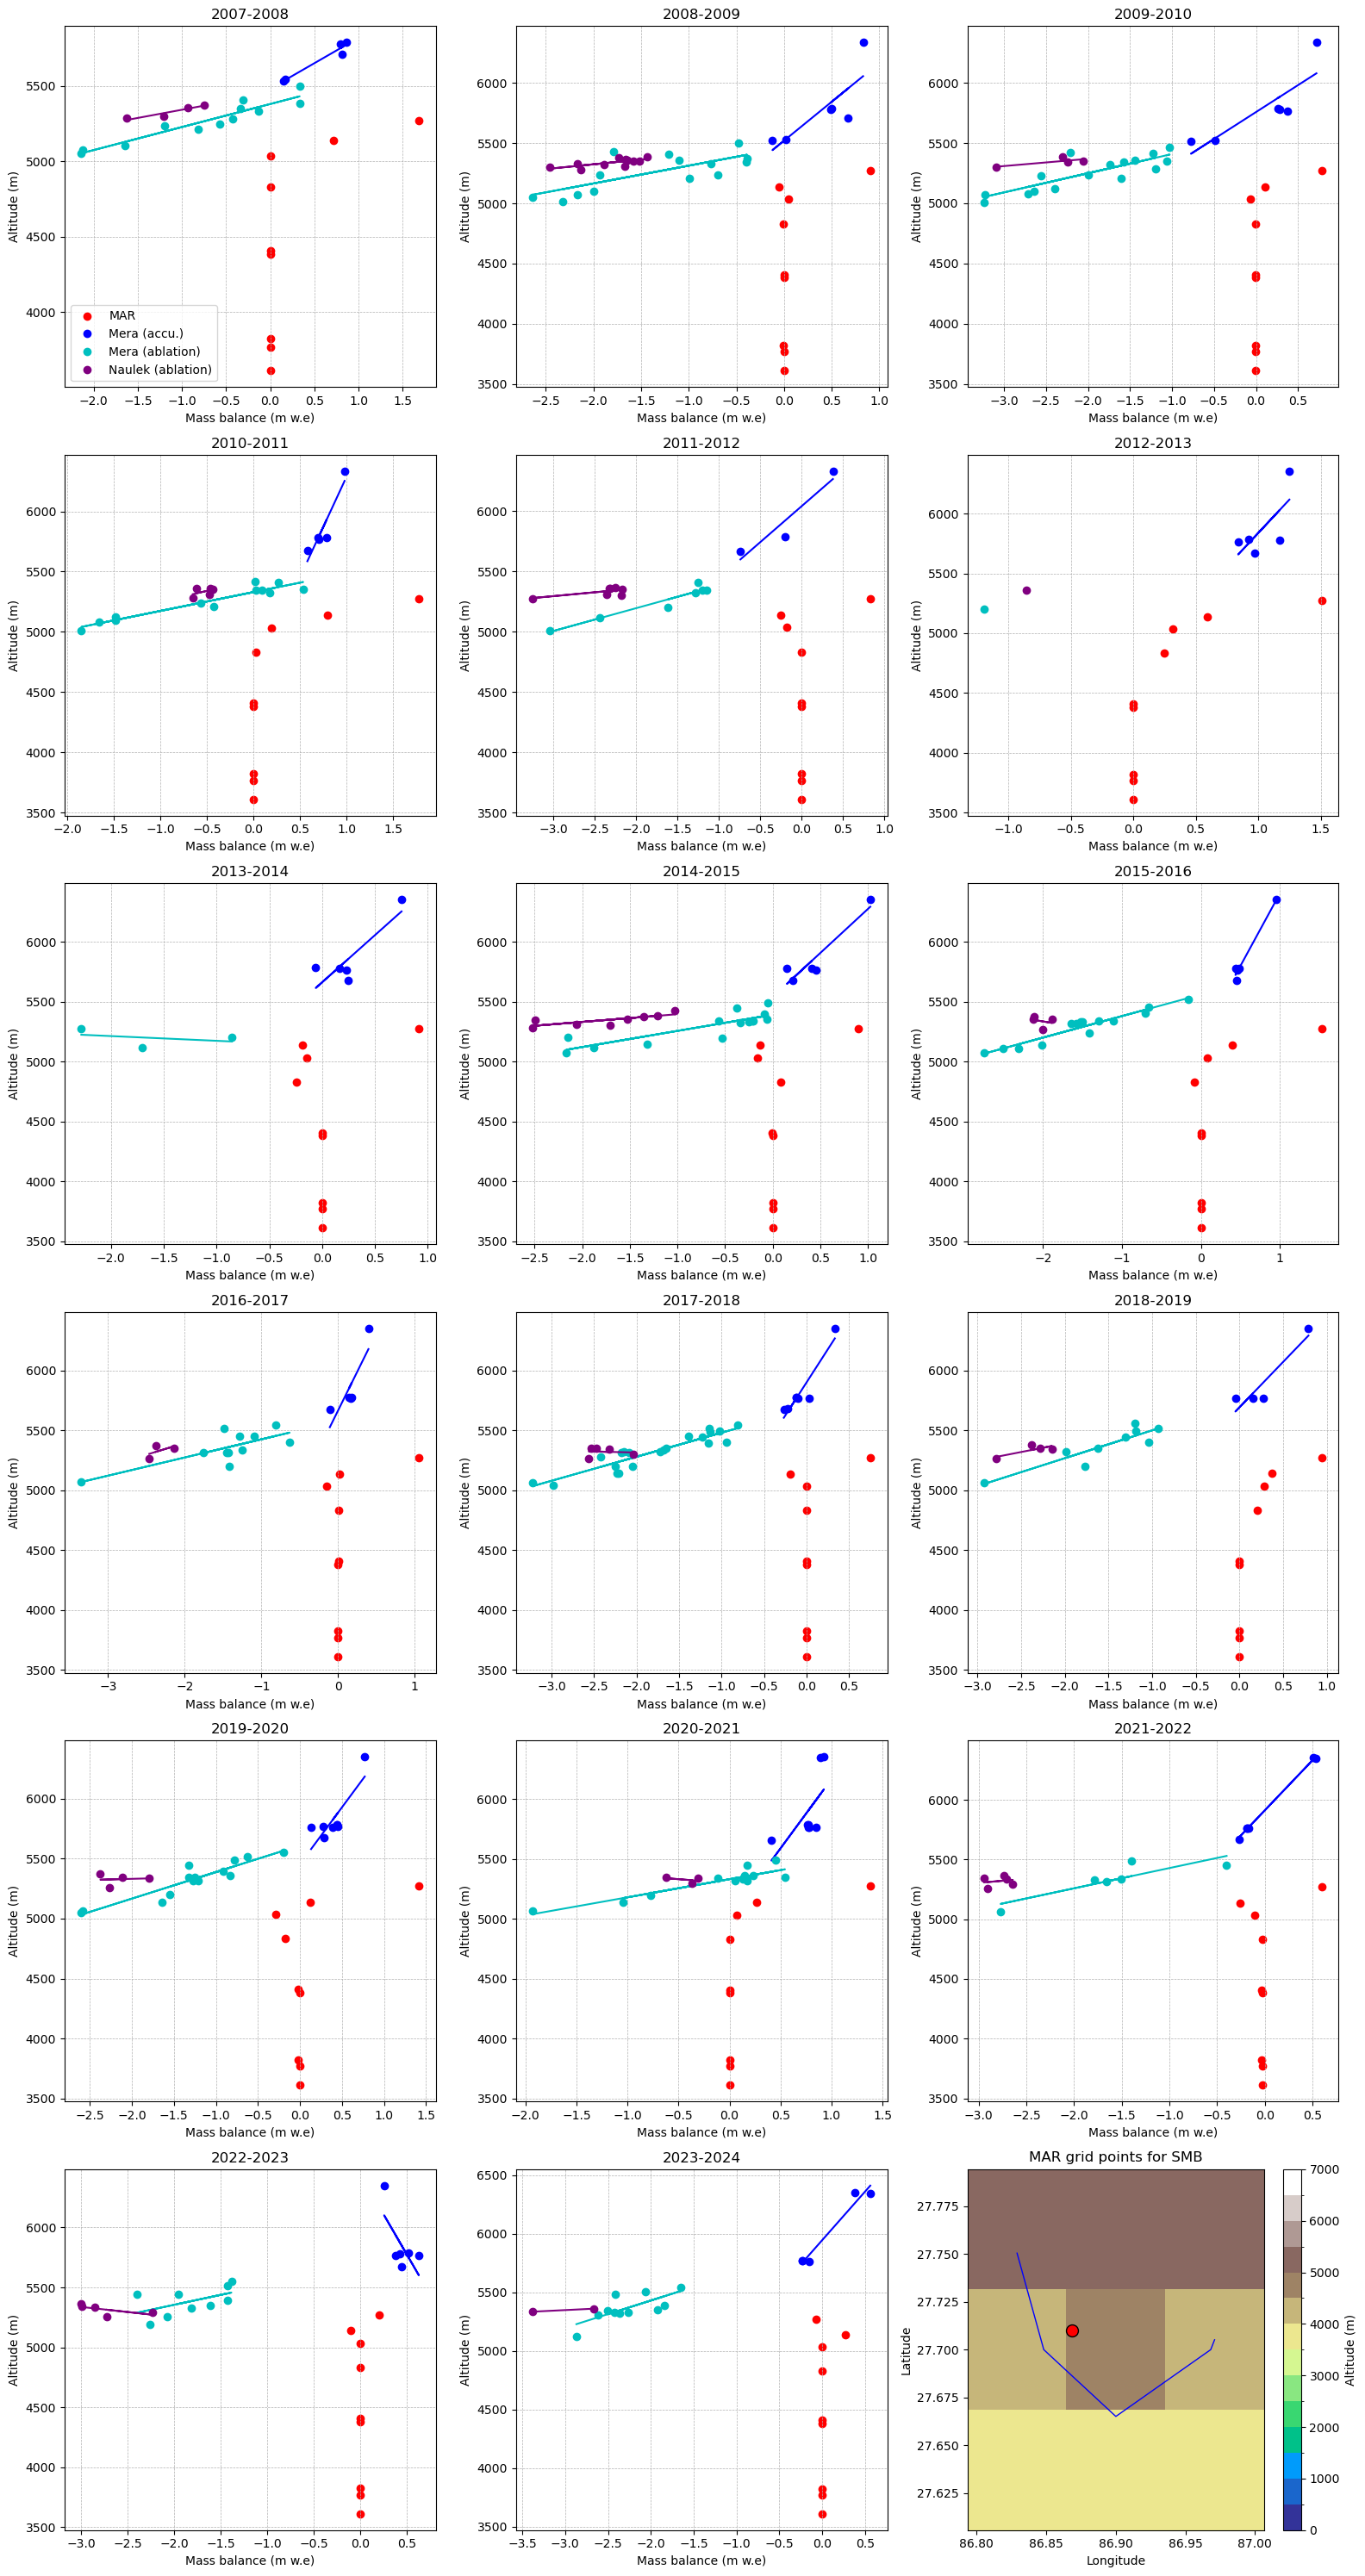

In [38]:
### 3x3 grid around Mera

Ydown, Yup, Xleft, Xright = iY-1, iY+2, iX-1, iX+2 # Choix du maillage en fonction de la position iY et iX de la grille du Mera

col = 3
line = int(np.ceil(nyy/col)) # Arrondi à l'entier supérieur le nombre de colonne à plot, et le met au format 'nombre entier'
fig, axes = plt.subplots(line,col,figsize=(16,5*line))
axes = axes.flatten() # Transforme le tableau 2D en tableau 1D (accessible avec 1 indice (j))


####### Grid on last subplot ######
ax = axes[nyy]
ds_SH_khumbu = ds_SH.isel(y=slice(Ydown, Yup), x=slice(Xleft, Xright)) # Selectionne le SMB sur les grilles données
ds_ICE_khumbu = ds_ICE.isel(y=slice(Ydown, Yup), x=slice(Xleft, Xright))
ds_lat_khumbu = ds_lat.isel(y=slice(Ydown, Yup), x=slice(Xleft, Xright)) # Selectionne les lon lat pour les plot
ds_lon_khumbu = ds_lon.isel(y=slice(Ydown, Yup), x=slice(Xleft, Xright))

plt.contour(ds_lon_khumbu, ds_lat_khumbu, ds_ICE_khumbu, levels=[ice_level], colors="b", linewidths=1) # Contours glaciers
ax.plot(merap_lon, merap_lat, marker='o', markersize=10, markeredgecolor='black', markerfacecolor='red') # Mera peak

pcm = ax.pcolormesh(ds_lon_khumbu, ds_lat_khumbu, ds_SH_khumbu, cmap=cmap, norm=norm, shading='auto')
fig.colorbar(pcm, ax=ax, label="Altitude (m)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("MAR grid points for SMB")


####### Subplot filling ###### 
for j in range(nyy):
    ax = axes[j] # Remplissage subplot avec indice de la boucle

    ###### MAR_data loading and sorting  ######    
    SMB_day2 = SMB_year[j].sel(TIME=slice(date_ref[j], date_obs[j])).isel(Y=slice(Ydown, Yup), X=slice(Xleft, Xright)) # Valeurs du SMB entre les deux dates de mesures (glacioclim)
    SMB_sum2 = SMB_day2.sum(dim='TIME')/1000 # Somme l'entièreté de ces valeurs sur la période, et rapporte les millimètres en mètres
    SMB_MAR2 = SMB_sum2.values.flatten() 

    SH_MAR2 = ds_SH.isel(y=slice(Ydown, Yup), x=slice(Xleft, Xright)).values.flatten() # Altitude des grilles de MAR

    ax.scatter(SMB_MAR2, SH_MAR2, color="r", label="MAR") # Affiche les points de MAR correspondant à la date des obs

    ###### Plot OBSERVATIONS ######
    ###### Accumulation
    ax.plot(SMB_accu_m[j], SH_accu_m[j], linestyle="", marker="o", color='b', label='Mera (accu.)') # Mera accu
    ax.plot(SMB_accu_m[j], reg_accu_m[j].intercept + reg_accu_m[j].slope * SMB_accu_m[j], 'b') # Mera accu regression lineaire

    ###### Ablation
    ax.plot(SMB_ablation_m[j], SH_ablation_m[j], linestyle="", marker="o", color='c', label='Mera (ablation)') # Mera ablation
    ax.plot(SMB_ablation_m[j], reg_ablation_m[j].intercept + reg_ablation_m[j].slope * SMB_ablation_m[j], 'c') # Mera ablation regression
    ax.plot(SMB_ablation_n[j], SH_ablation_n[j], linestyle="", marker="o", color='purple', label='Naulek (ablation)') # Naulek ablation
    ax.plot(SMB_ablation_n[j], reg_ablation_n[j].intercept + reg_ablation_n[j].slope * SMB_ablation_n[j], 'purple') # Naulek ablation regression
 
    ###### Graphic features ######
    ax.set_title(f"20{yy[j]}-20{yy[j+1]}")
    ax.set_xlabel("Mass balance (m w.e)")
    ax.set_ylabel("Altitude (m)")
    ax.grid(linestyle = '--', linewidth = 0.5)
    #ax.set_xlim(-4, 2) # Restriction du domaine 
    #ax.set_ylim(4700, 6400) # Restriction du domaine 
    
    if j == 0: # Affiche la légende pour la première figure
        ax.legend()

plt.tight_layout()

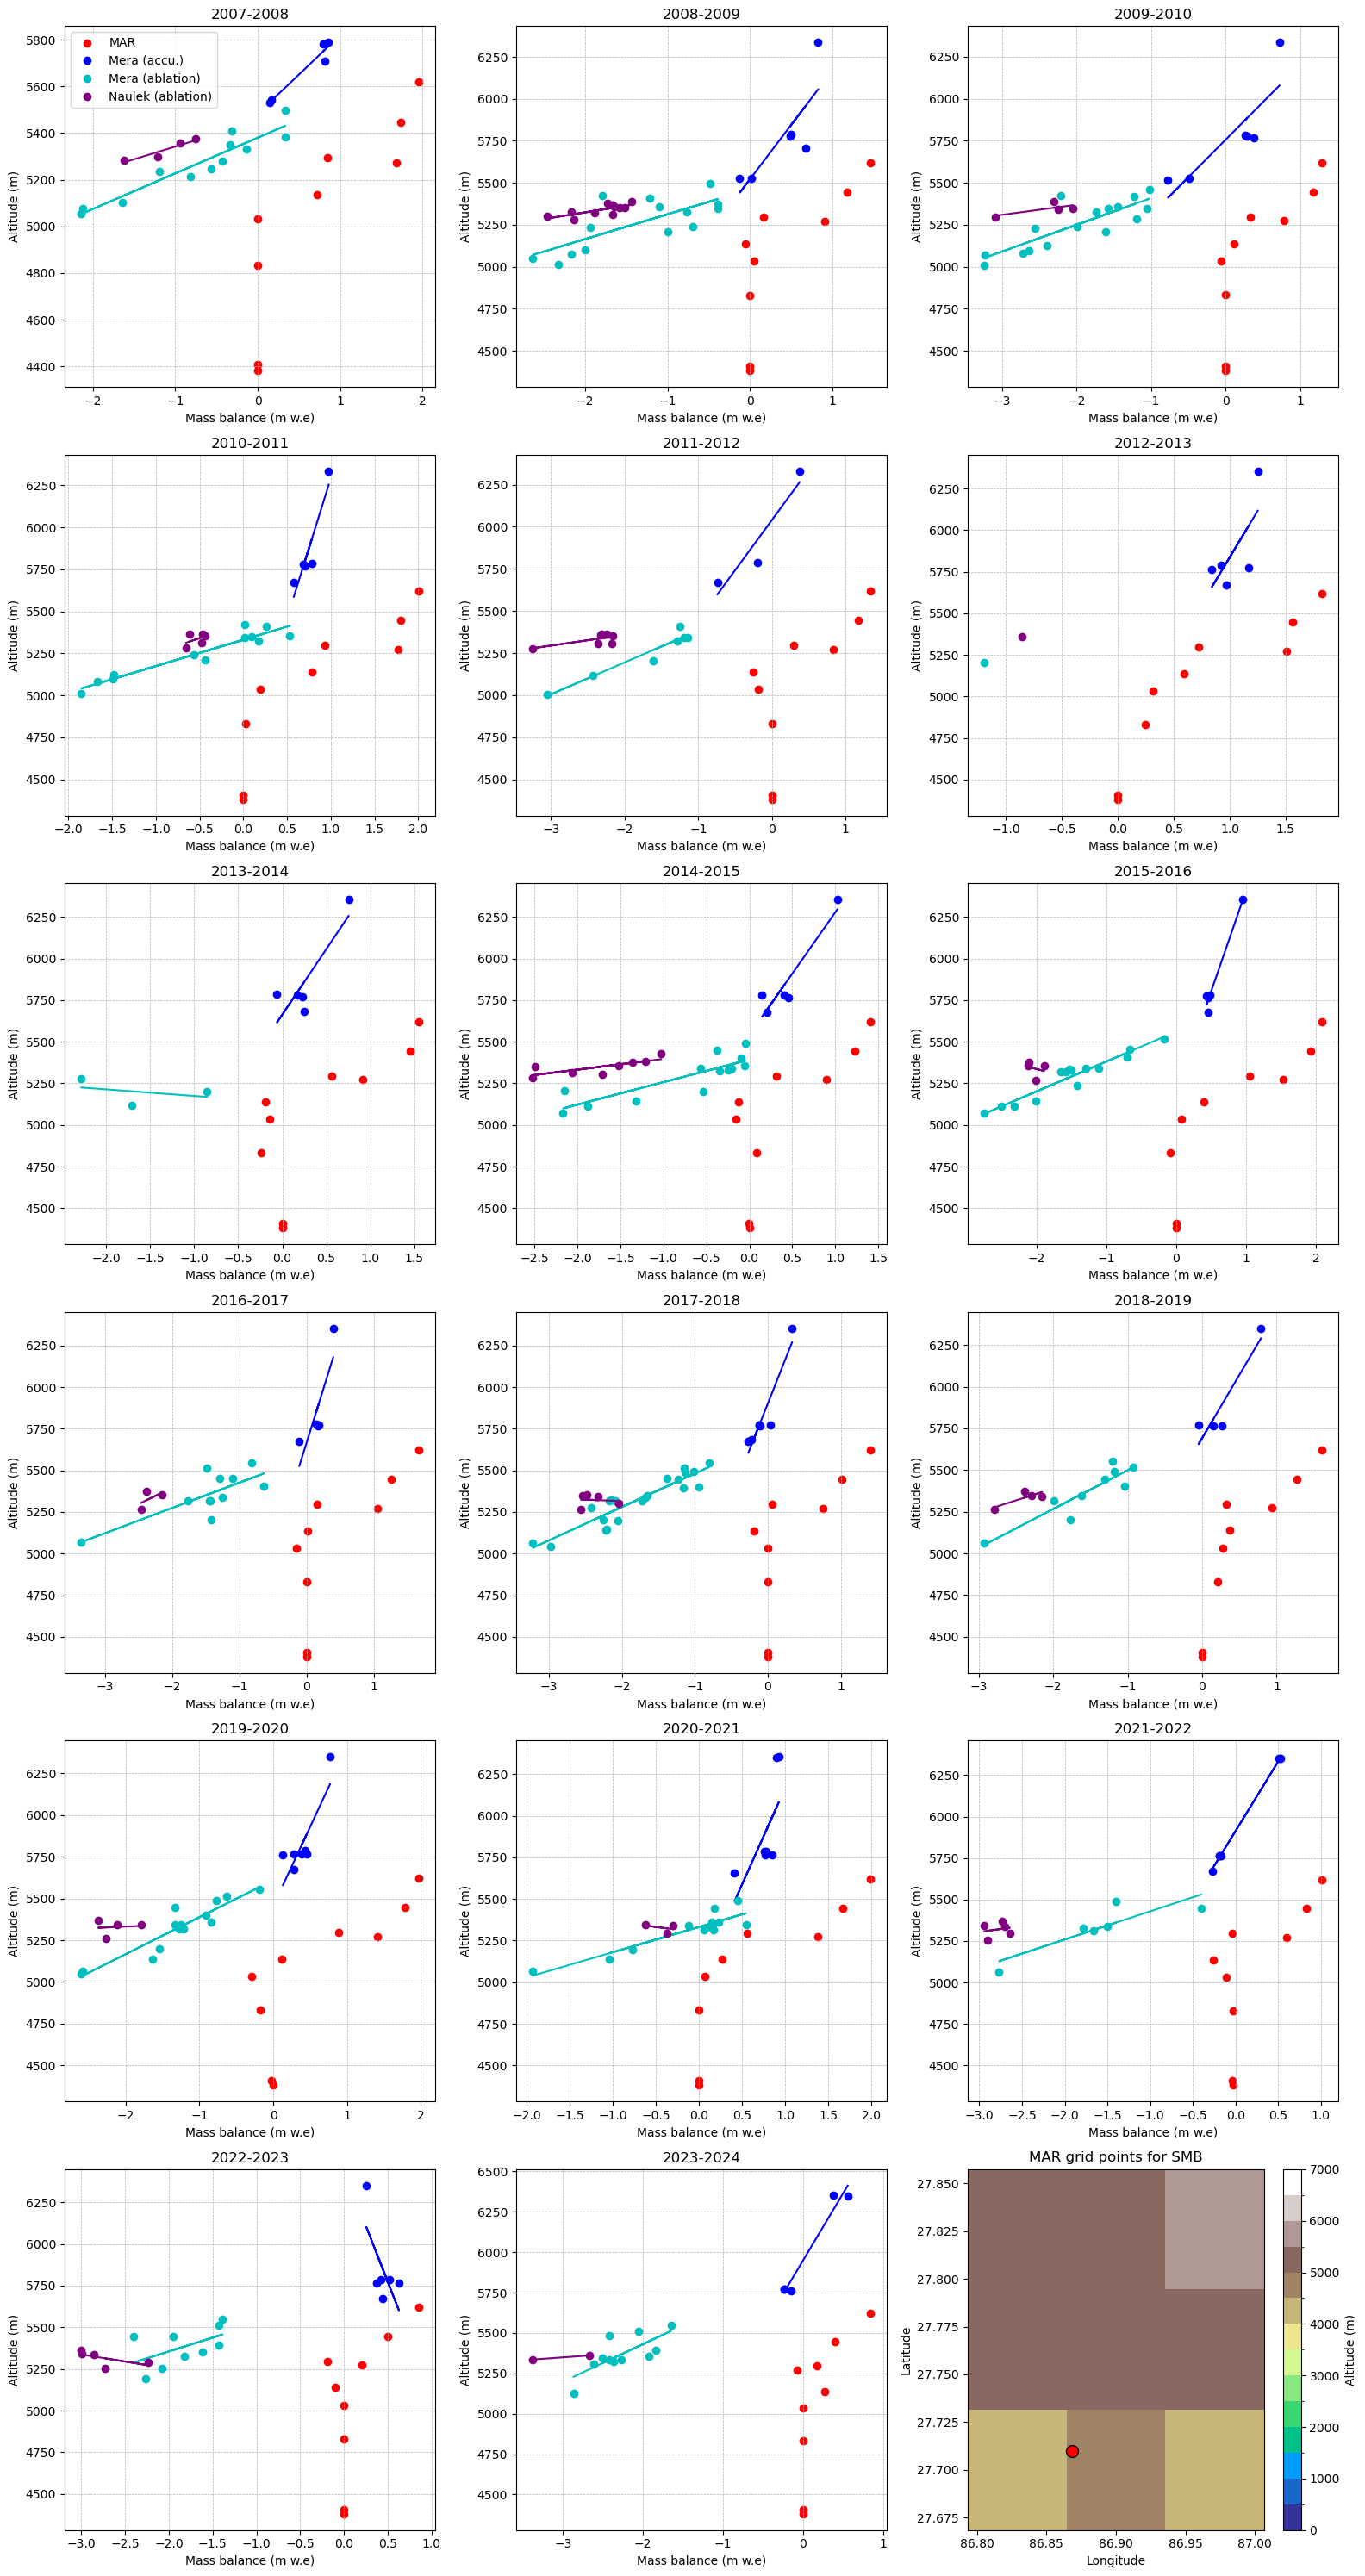

In [39]:
### 3x3 grid North of Mera

Ydown, Yup, Xleft, Xright = iY, iY+3, iX-1, iX+2 # Choix du maillage en fonction de la position iY et iX de la grille du Mera

col = 3
line = int(np.ceil(nyy/col)) # Arrondi à l'entier supérieur le nombre de colonne à plot, et le met au format 'nombre entier'
fig, axes = plt.subplots(line,col,figsize=(16,5*line))
axes = axes.flatten() # Transforme le tableau 2D en tableau 1D (accessible avec 1 indice (j))


####### Grid on last subplot ######
ax = axes[nyy]
ds_SH3 = ds_SH.isel(y=slice(Ydown, Yup), x=slice(Xleft, Xright)) # Selectionne le SMB sur les grilles données
ds_lat_mera3 = ds_lat.isel(y=slice(Ydown, Yup), x=slice(Xleft, Xright)) # Selectionne les lon lat pour les plot
ds_lon_mera3 = ds_lon.isel(y=slice(Ydown, Yup), x=slice(Xleft, Xright))

ax.plot(merap_lon, merap_lat, marker='o', markersize=10, markeredgecolor='black', markerfacecolor='red') # Mera peak

pcm = ax.pcolormesh(ds_lon_mera3, ds_lat_mera3, ds_SH3, cmap=cmap, norm=norm, shading='auto')
fig.colorbar(pcm, ax=ax, label="Altitude (m)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("MAR grid points for SMB")


####### Subplot filling ###### 
for j in range(nyy):
    ax = axes[j] # Remplissage subplot avec indice de la boucle

    ###### MAR_data loading and sorting  ######    
    SMB_day3 = SMB_year[j].sel(TIME=slice(date_ref[j], date_obs[j])).isel(Y=slice(Ydown, Yup), X=slice(Xleft, Xright)) # Valeurs du SMB entre les deux dates de mesures (glacioclim)
    SMB_sum3 = SMB_day3.sum(dim='TIME')/1000 # Somme l'entièreté de ces valeurs sur la période, et rapporte les millimètres en mètres
    SMB_MAR3 = SMB_sum3.values.flatten() 

    SH_MAR3 = ds_SH.isel(y=slice(Ydown, Yup), x=slice(Xleft, Xright)).values.flatten() # Altitude des grilles de MAR

    ax.scatter(SMB_MAR3, SH_MAR3, color="r", label="MAR") # Affiche les points de MAR correspondant à la date des obs

    ###### Plot OBSERVATIONS ######
    ###### Accumulation
    ax.plot(SMB_accu_m[j], SH_accu_m[j], linestyle="", marker="o", color='b', label='Mera (accu.)') # Mera accu
    ax.plot(SMB_accu_m[j], reg_accu_m[j].intercept + reg_accu_m[j].slope * SMB_accu_m[j], 'b') # Mera accu regression lineaire

    ###### Ablation
    ax.plot(SMB_ablation_m[j], SH_ablation_m[j], linestyle="", marker="o", color='c', label='Mera (ablation)') # Mera ablation
    ax.plot(SMB_ablation_m[j], reg_ablation_m[j].intercept + reg_ablation_m[j].slope * SMB_ablation_m[j], 'c') # Mera ablation regression
    ax.plot(SMB_ablation_n[j], SH_ablation_n[j], linestyle="", marker="o", color='purple', label='Naulek (ablation)') # Naulek ablation
    ax.plot(SMB_ablation_n[j], reg_ablation_n[j].intercept + reg_ablation_n[j].slope * SMB_ablation_n[j], 'purple') # Naulek ablation regression
  
    ###### Graphic features ######
    ax.set_title(f"20{yy[j]}-20{yy[j+1]}")
    ax.set_xlabel("Mass balance (m w.e)")
    ax.set_ylabel("Altitude (m)")
    ax.grid(linestyle = '--', linewidth = 0.5)

    if j == 0: # Affiche la légende pour la première figure
        ax.legend()

plt.tight_layout()

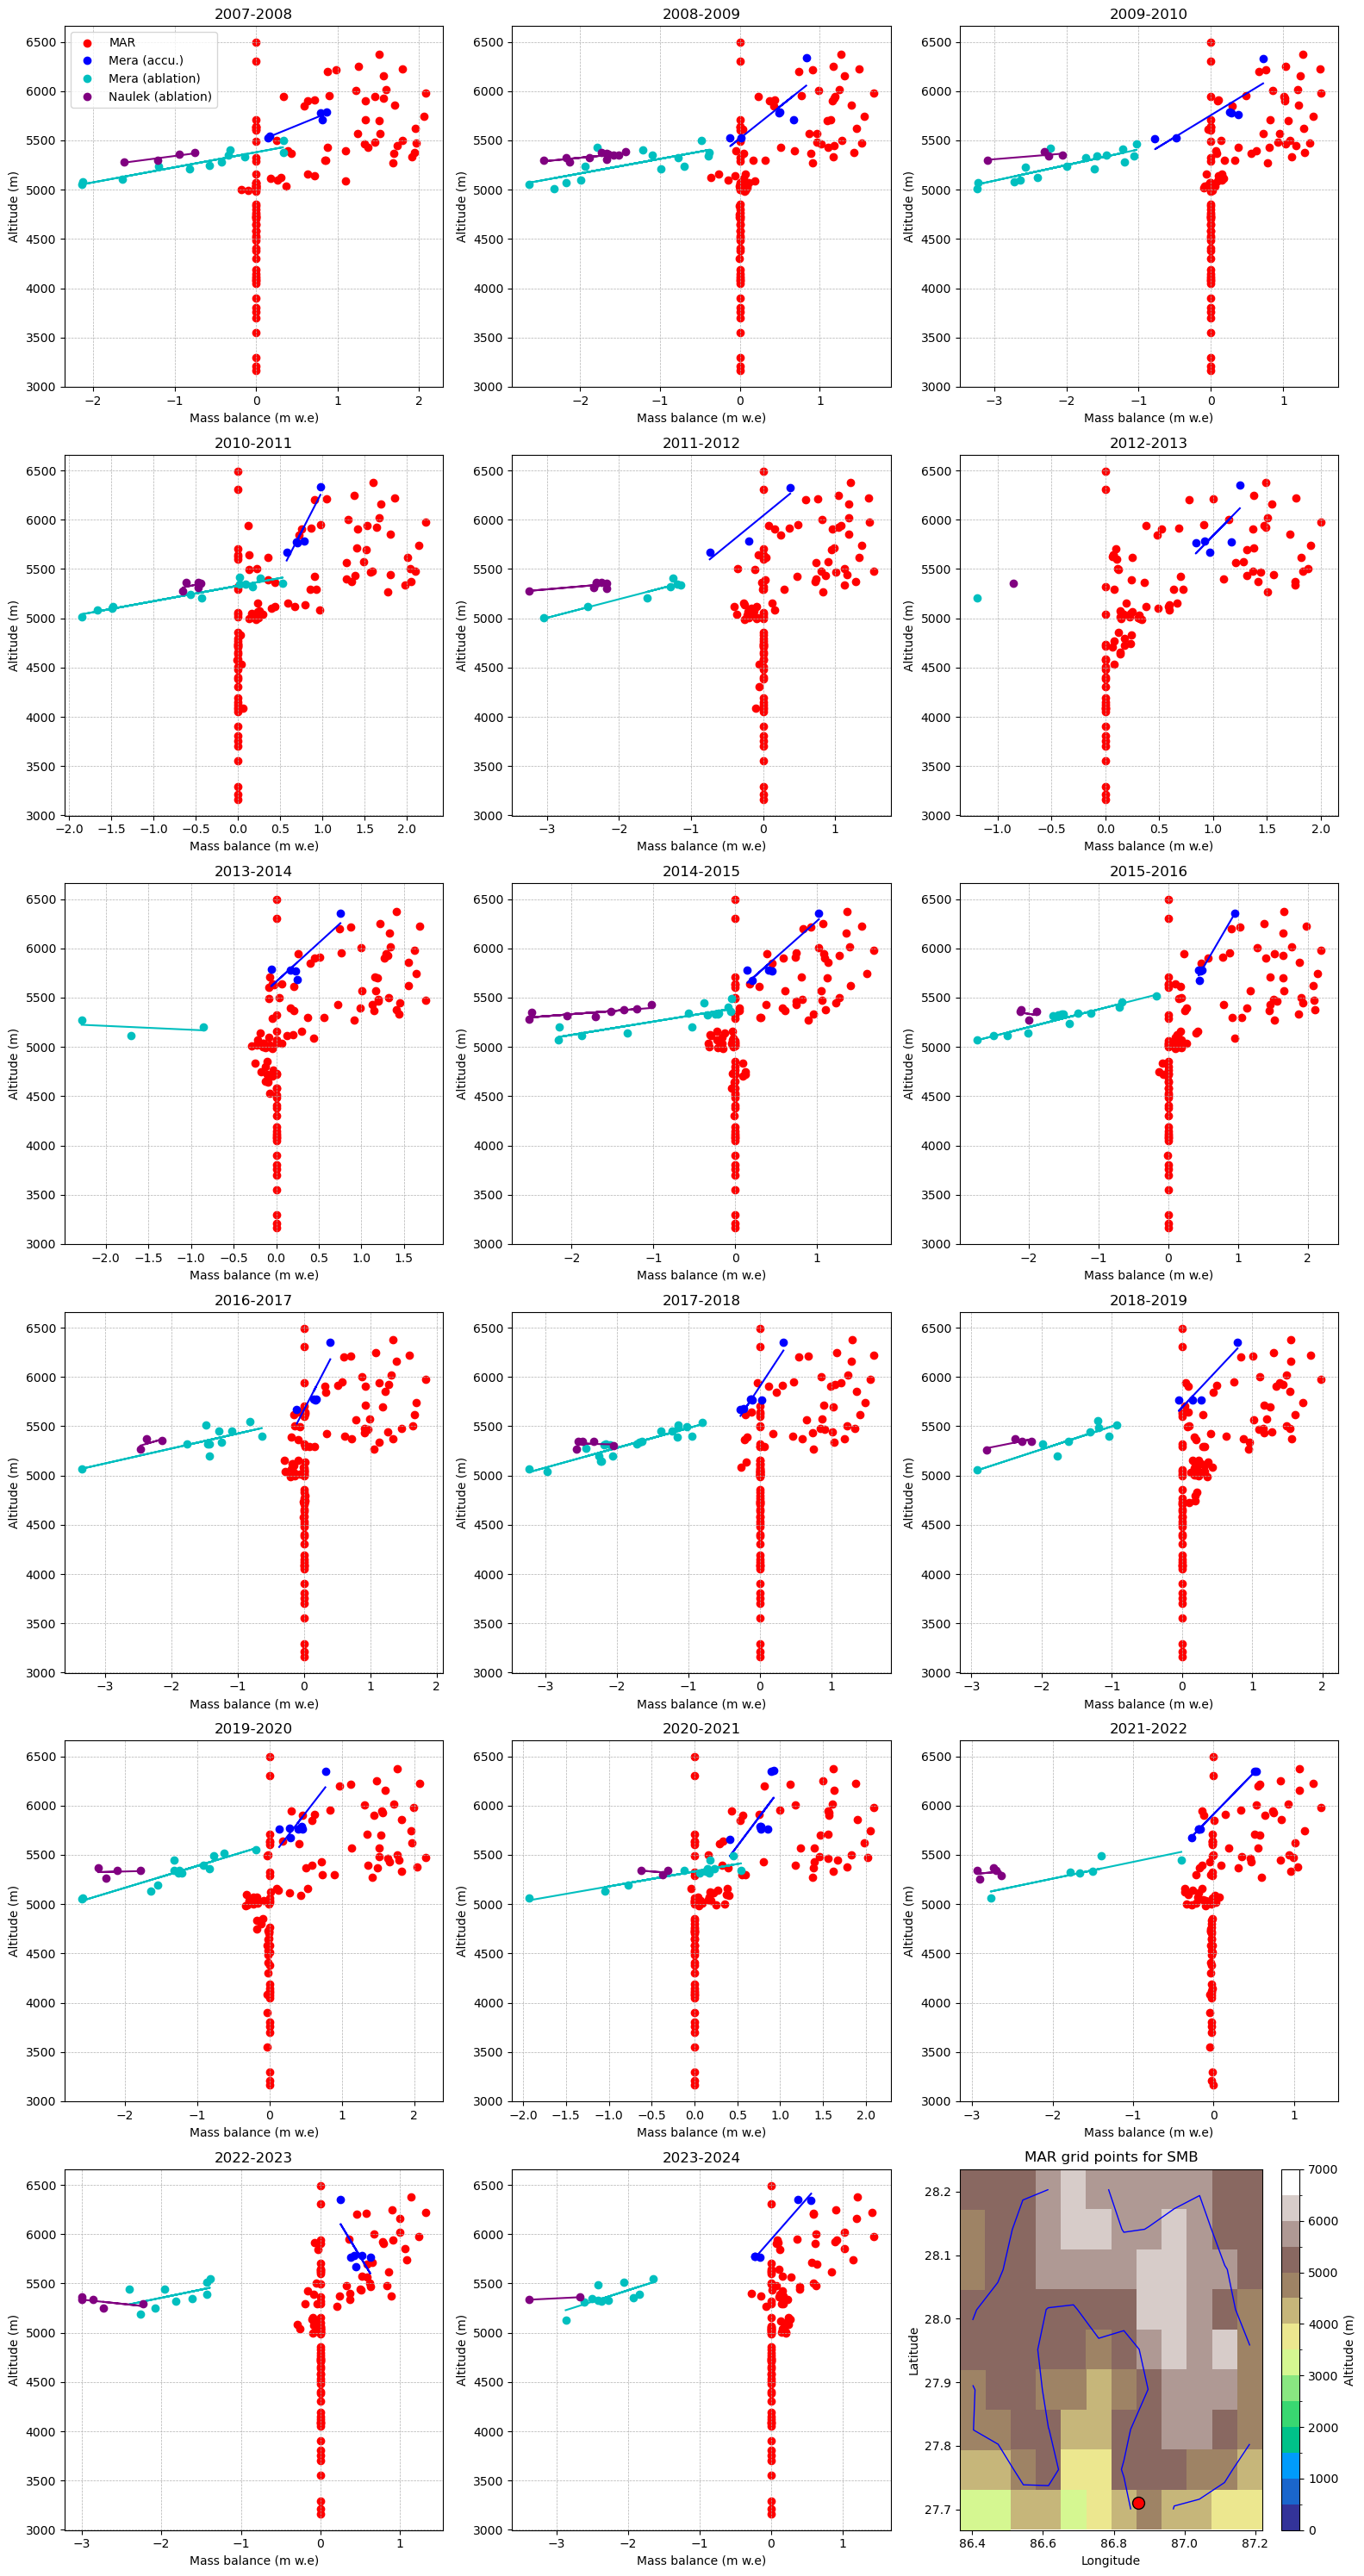

In [40]:
### Khumbu domain

Ydown, Yup, Xleft, Xright = iY, iY+9, iX-7, iX+5 # Choix du maillage en fonction de la position iY et iX de la grille du Mera

col = 3
line = int(np.ceil(nyy/col)) # Arrondi à l'entier supérieur le nombre de colonne à plot, et le met au format 'nombre entier'
fig, axes = plt.subplots(line,col,figsize=(16,5*line))
axes = axes.flatten() # Transforme le tableau 2D en tableau 1D (accessible avec 1 indice (j))

SMB_list_khumbu = []

####### Grid on last subplot ######
ax = axes[nyy]
ds_SH_khumbu = ds_SH.isel(y=slice(Ydown, Yup), x=slice(Xleft, Xright)) # Selectionne le SMB sur les grilles données
ds_ICE_khumbu = ds_ICE.isel(y=slice(Ydown, Yup), x=slice(Xleft, Xright))
ds_lat_khumbu = ds_lat.isel(y=slice(Ydown, Yup), x=slice(Xleft, Xright)) # Selectionne les lon lat pour les plot
ds_lon_khumbu = ds_lon.isel(y=slice(Ydown, Yup), x=slice(Xleft, Xright))

plt.contour(ds_lon_khumbu, ds_lat_khumbu, ds_ICE_khumbu, levels=[ice_level], colors="b", linewidths=1) # Contours glaciers
ax.plot(merap_lon, merap_lat, marker='o', markersize=10, markeredgecolor='black', markerfacecolor='red') # Mera peak

pcm = ax.pcolormesh(ds_lon_khumbu, ds_lat_khumbu, ds_SH_khumbu, cmap=cmap, norm=norm, shading='auto')
fig.colorbar(pcm, ax=ax, label="Altitude (m)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("MAR grid points for SMB")


####### Subplot filling ###### 
for j in range(nyy):
    ax = axes[j] # Remplissage subplot avec indice de la boucle

    ###### MAR_data loading and sorting  ######    
    SMB_day_khumbu = SMB_year[j].sel(TIME=slice(date_ref[j], date_obs[j])).isel(Y=slice(Ydown, Yup), X=slice(Xleft, Xright)) # Valeurs du SMB entre les deux dates de mesures (glacioclim)
    SMB_sum_khumbu = SMB_day_khumbu.sum(dim='TIME')/1000 # Somme l'entièreté des valeurs journalière sur la période, et rapporte les millimètres en mètres
    SMB_MAR_khumbu = SMB_sum_khumbu.values.flatten()
    #print('SMB_allgrid_khumbu'+yy[j]+'-'+yy[j+1]+' =', SMB_sum_khumbu, 'm w.e/yr')    

    # Prepare les données pour les plot en série temporelle (ici on retire les valeurs de SMB=0)
    SMB_regional = SMB_sum_khumbu.where(SMB_sum_khumbu != 0).mean(dim=["Y","X"]).values # Fais la moyenne des SMB de chaque point de grille du khumbu pour chaque année
    #print('SMB_khumbu'+yy[j]+'-'+yy[j+1]+' =', SMB_regional, 'm w.e/yr')    
    SMB_list_khumbu.append(SMB_regional)
    
    SH_MAR_khumbu = ds_SH.isel(y=slice(Ydown, Yup), x=slice(Xleft, Xright)).values.flatten() # Altitude des grilles de MAR

    ax.scatter(SMB_MAR_khumbu, SH_MAR_khumbu, color="r", label="MAR") # Affiche les points de MAR correspondant à la date des obs

    ###### Plot OBSERVATIONS ######
    ###### Accumulation
    ax.plot(SMB_accu_m[j], SH_accu_m[j], linestyle="", marker="o", color='b', label='Mera (accu.)') # Mera accu
    ax.plot(SMB_accu_m[j], reg_accu_m[j].intercept + reg_accu_m[j].slope * SMB_accu_m[j], 'b') # Mera accu regression lineaire

    ###### Ablation
    ax.plot(SMB_ablation_m[j], SH_ablation_m[j], linestyle="", marker="o", color='c', label='Mera (ablation)') # Mera ablation
    ax.plot(SMB_ablation_m[j], reg_ablation_m[j].intercept + reg_ablation_m[j].slope * SMB_ablation_m[j], 'c') # Mera ablation regression
    ax.plot(SMB_ablation_n[j], SH_ablation_n[j], linestyle="", marker="o", color='purple', label='Naulek (ablation)') # Naulek ablation
    ax.plot(SMB_ablation_n[j], reg_ablation_n[j].intercept + reg_ablation_n[j].slope * SMB_ablation_n[j], 'purple') # Naulek ablation regression
   
    ###### Graphic features ######
    ax.set_title(f"20{yy[j]}-20{yy[j+1]}")
    ax.set_xlabel("Mass balance (m w.e)")
    ax.set_ylabel("Altitude (m)")
    ax.grid(linestyle = '--', linewidth = 0.5)
    
    if j == 0: # Affiche la légende pour la première figure
        ax.legend()

plt.tight_layout()

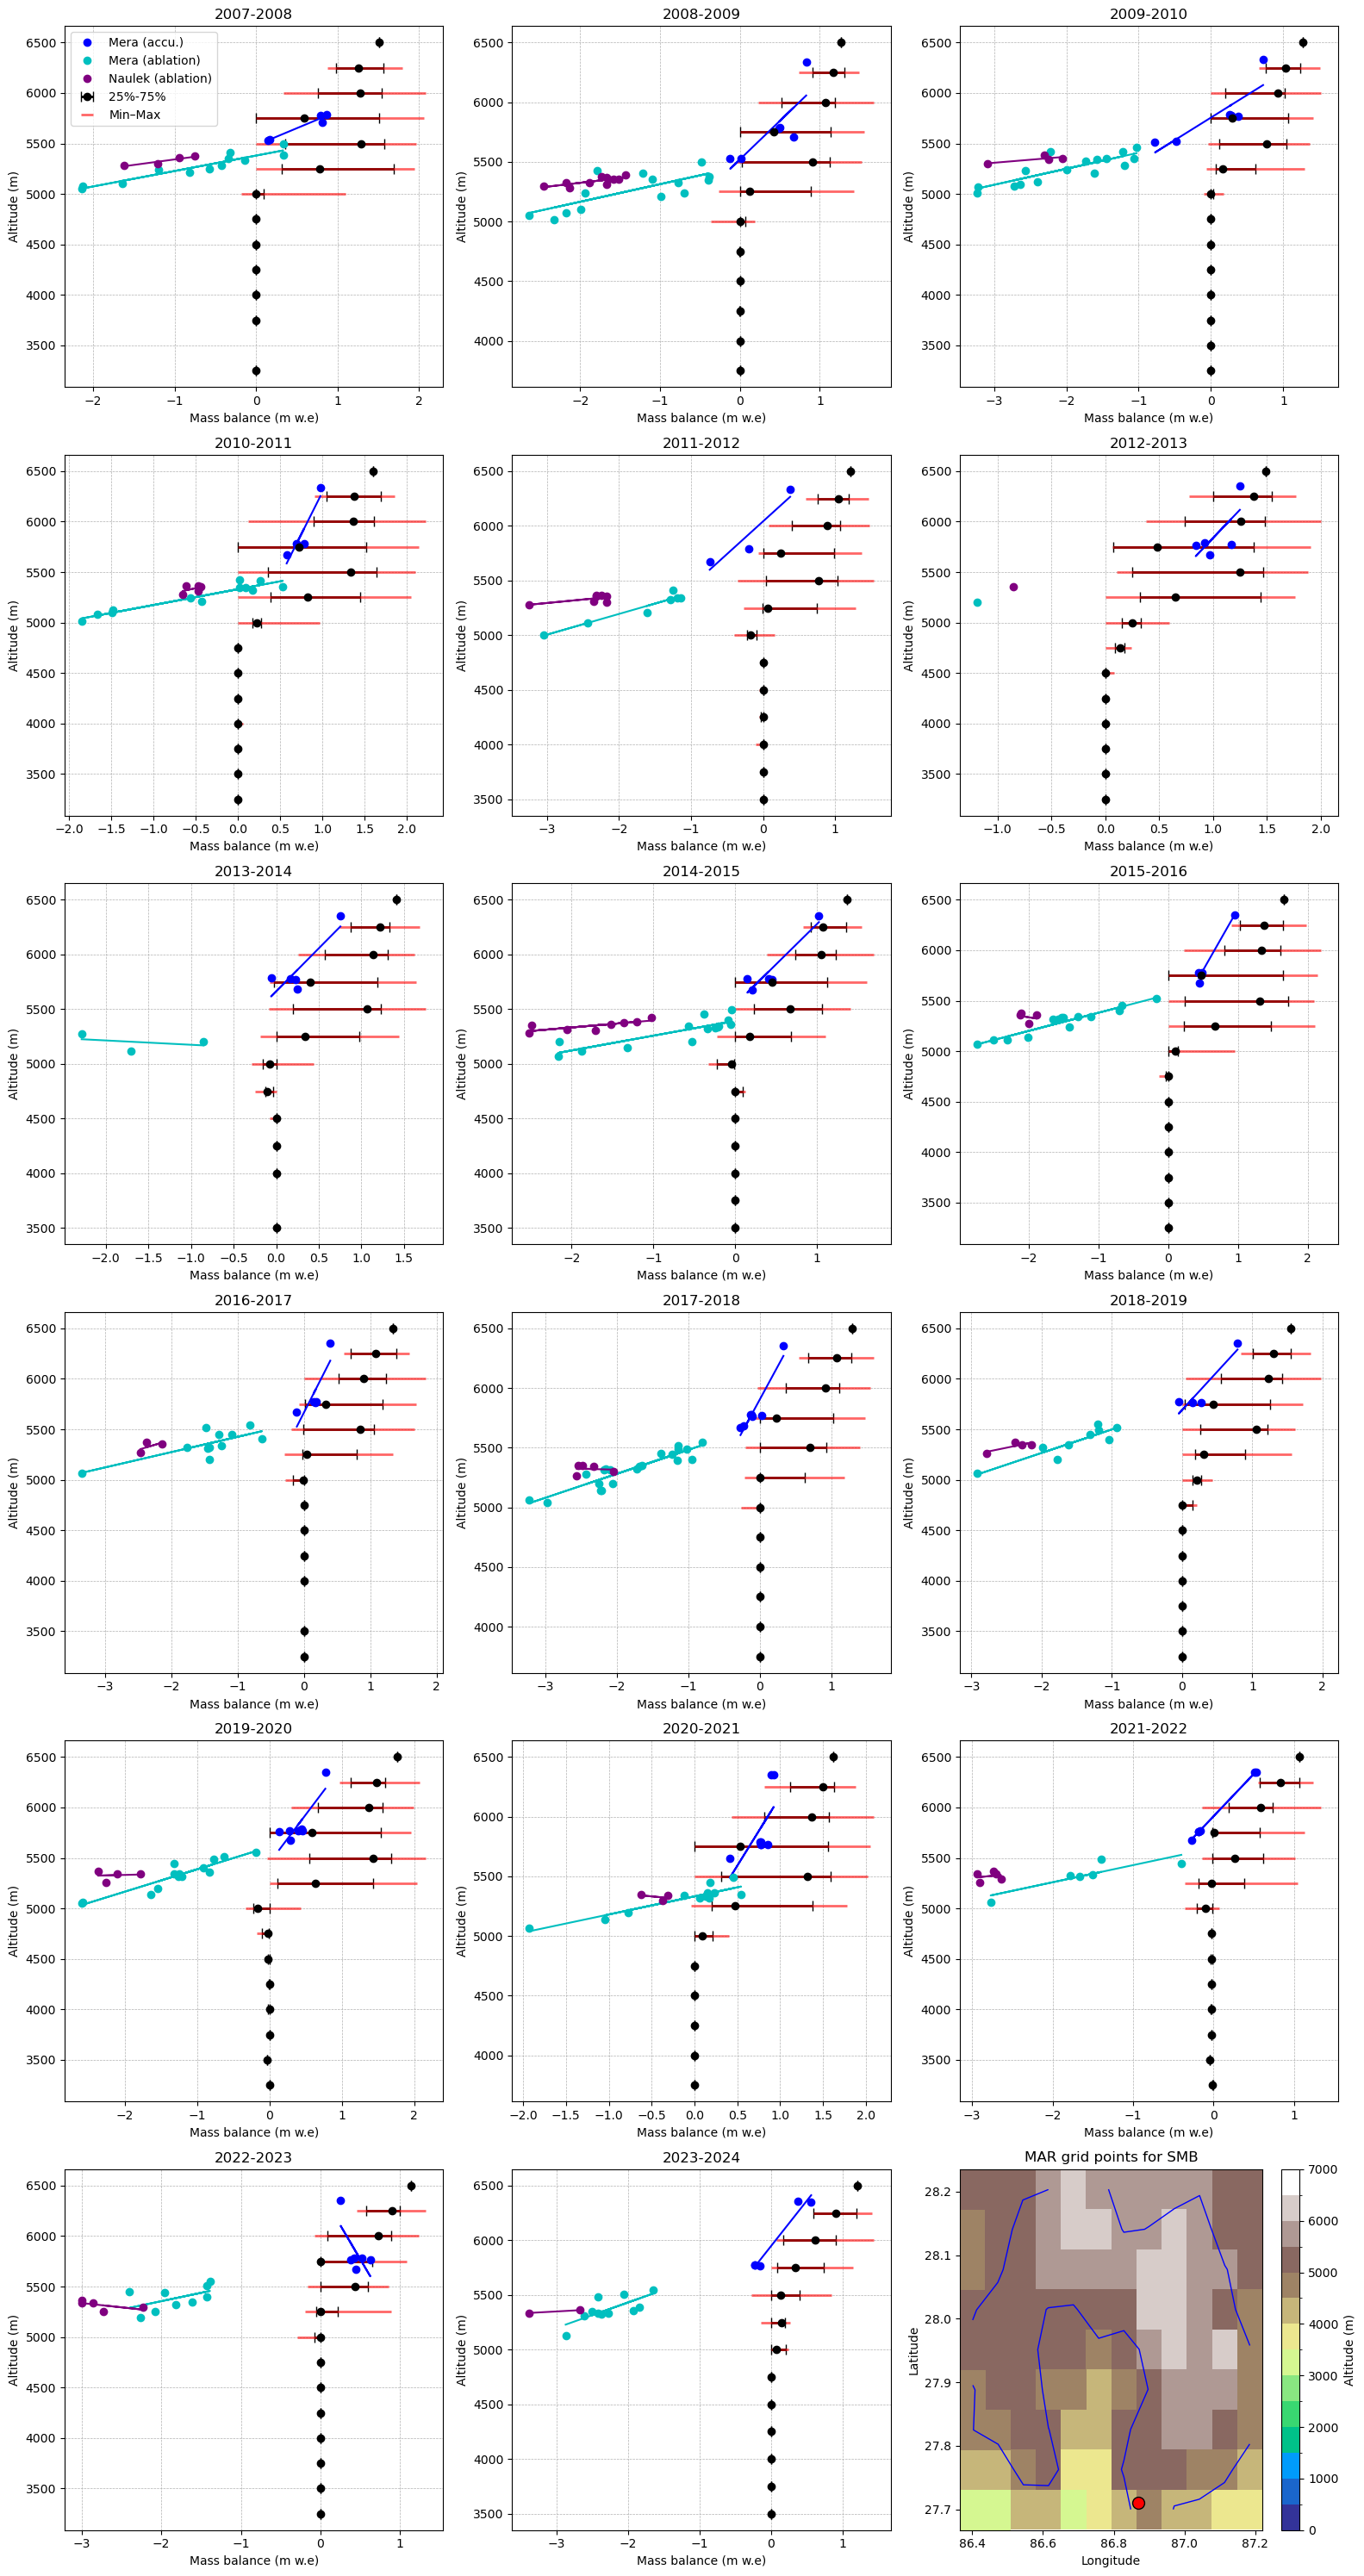

In [41]:
### Khumbu alt band

Ydown, Yup, Xleft, Xright = iY, iY+9, iX-7, iX+5 # Choix du maillage en fonction de la position iY et iX de la grille du Mera

col = 3
line = int(np.ceil(nyy/col)) # Arrondi à l'entier supérieur le nombre de colonne à plot, et le met au format 'nombre entier'
fig, axes = plt.subplots(line,col,figsize=(16,5*line))
axes = axes.flatten() # Transforme le tableau 2D en tableau 1D (accessible avec 1 indice (j))


####### Grid on last subplot ######
ax = axes[nyy]

plt.contour(ds_lon_khumbu, ds_lat_khumbu, ds_ICE_khumbu, levels=[ice_level], colors="b", linewidths=1) # Contours glaciers
ax.plot(merap_lon, merap_lat, marker='o', markersize=10, markeredgecolor='black', markerfacecolor='red') # Mera peak

pcm = ax.pcolormesh(ds_lon_khumbu, ds_lat_khumbu, ds_SH_khumbu, cmap=cmap, norm=norm, shading='auto')
fig.colorbar(pcm, ax=ax, label="Altitude (m)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("MAR grid points for SMB")

###### Subplot filling ######
for j in range(nyy):
    ax = axes[j] # Remplissage subplot avec indice de la boucle

    ###### MAR_data loading and sorting  ######    
    SMB_day_khumbu = SMB_year[j].sel(TIME=slice(date_ref[j], date_obs[j])).isel(Y=slice(Ydown, Yup), X=slice(Xleft, Xright)) # Valeurs du SMB entre les deux dates de mesures (glacioclim)
    SMB_sum_khumbu = SMB_day_khumbu.sum(dim='TIME')/1000 # Somme l'entièreté de ces valeurs sur la période, et rapporte les millimètres en mètres
    SMB_MAR_khumbu = SMB_sum_khumbu.values.flatten() 

    SH_MAR_khumbu = ds_SH.isel(y=slice(Ydown, Yup), x=slice(Xleft, Xright)).values.flatten() # Altitude des grilles de MAR

    #### Création des classes d'altitude (pas de 250 m)
    alt_band = np.arange(125, 7000, 250)
    alt_classes = np.digitize(SH_MAR_khumbu, alt_band) # Digitize permet de mettre dans les classes d'altitude les différentes grilles selon leur altitudes sous forme de liste [1,2,2,1,3,2]

    SMB_min, SMB_max, SMB_p50, SMB_p25, SMB_p75, alt_center = [], [], [], [], [], [] # Définition des listes des percentilles, min et max de chaque classe d'alt

    for a in np.unique(alt_classes): # Comme alt_classes est une liste donnant un indice à chaque point de grille en fonction de l'altitude. np.unique ne regarde qu'une fois un indice déjà vu
        # Création d'un mask "m" qui va prendre la forme m = [False, True, True, False...] avec une condition sur si la classe et sur si la valeur de SMB n'est pas nulle
        m = (alt_classes == a) & (SMB_MAR_khumbu != 0) 

        smbk = SMB_MAR_khumbu[m]
        shk = SH_MAR_khumbu[m]

        if len(smbk) == 0:   # Si la liste smbk pour une classe d'alt est vide (cad que tous les smb pour cette alt sont nuls), on passe à l'itération suivante pour éviter un bug dans la boucle
            continue

        p25 = np.percentile(smbk, 25)
        p50 = np.percentile(smbk, 50)   # médiane
        p75 = np.percentile(smbk, 75)
        
        # Grâce au mask, on peut alors faire des opérations sur les variables restreintes aux bandes d'altitudes
        SMB_p25.append(p25)
        SMB_p50.append(p50)
        SMB_p75.append(p75)
        SMB_min.append(np.min(smbk))
        SMB_max.append(np.max(smbk))
        
        #alt_center.append(np.mean(shk))
        alt_center.append(alt_band[a-1] + 125) # Affiche simplement le centre de la bande sans moyenner ("a-1" car digitize a un indice qui commence par 1)

    SMB_p25 = np.array(SMB_p25) # Transformation des listes en tableaux pour pouvoir les plot
    SMB_p50 = np.array(SMB_p50)
    SMB_p75 = np.array(SMB_p75)
    SMB_min = np.array(SMB_min)
    SMB_max = np.array(SMB_max)
    alt_center = np.array(alt_center)

    # Plot des percentilles avec xerr qui affiche une barre de couleur "ecolor", et de taille "capsize"
    ax.errorbar(SMB_p50, alt_center, xerr=[SMB_p50-SMB_p25, SMB_p75-SMB_p50], fmt="o", color="k", ecolor="k", elinewidth=2, capsize=4, label="25%-75%")

    ax.errorbar(SMB_p50, alt_center, xerr=[SMB_p50-SMB_min, SMB_max-SMB_p50], fmt="none", ecolor="r", elinewidth=2, alpha=0.6, label="Min–Max")
    
    ###### Plot OBSERVATIONS ######
    ###### Accumulation
    ax.plot(SMB_accu_m[j], SH_accu_m[j], linestyle="", marker="o", color='b', label='Mera (accu.)') # Mera accu
    ax.plot(SMB_accu_m[j], reg_accu_m[j].intercept + reg_accu_m[j].slope * SMB_accu_m[j], 'b') # Mera accu regression lineaire

    ###### Ablation
    ax.plot(SMB_ablation_m[j], SH_ablation_m[j], linestyle="", marker="o", color='c', label='Mera (ablation)') # Mera ablation
    ax.plot(SMB_ablation_m[j], reg_ablation_m[j].intercept + reg_ablation_m[j].slope * SMB_ablation_m[j], 'c') # Mera ablation regression
    ax.plot(SMB_ablation_n[j], SH_ablation_n[j], linestyle="", marker="o", color='purple', label='Naulek (ablation)') # Naulek ablation
    ax.plot(SMB_ablation_n[j], reg_ablation_n[j].intercept + reg_ablation_n[j].slope * SMB_ablation_n[j], 'purple') # Naulek ablation regression
    
    ###### Graphic features ######
    ax.set_title(f"20{yy[j]}-20{yy[j+1]}")
    ax.set_xlabel("Mass balance (m w.e)")
    ax.set_ylabel("Altitude (m)")
    ax.grid(linestyle = '--', linewidth = 0.5)
    
    if j == 0: # Affiche la légende pour la première figure
        ax.legend()

plt.tight_layout()

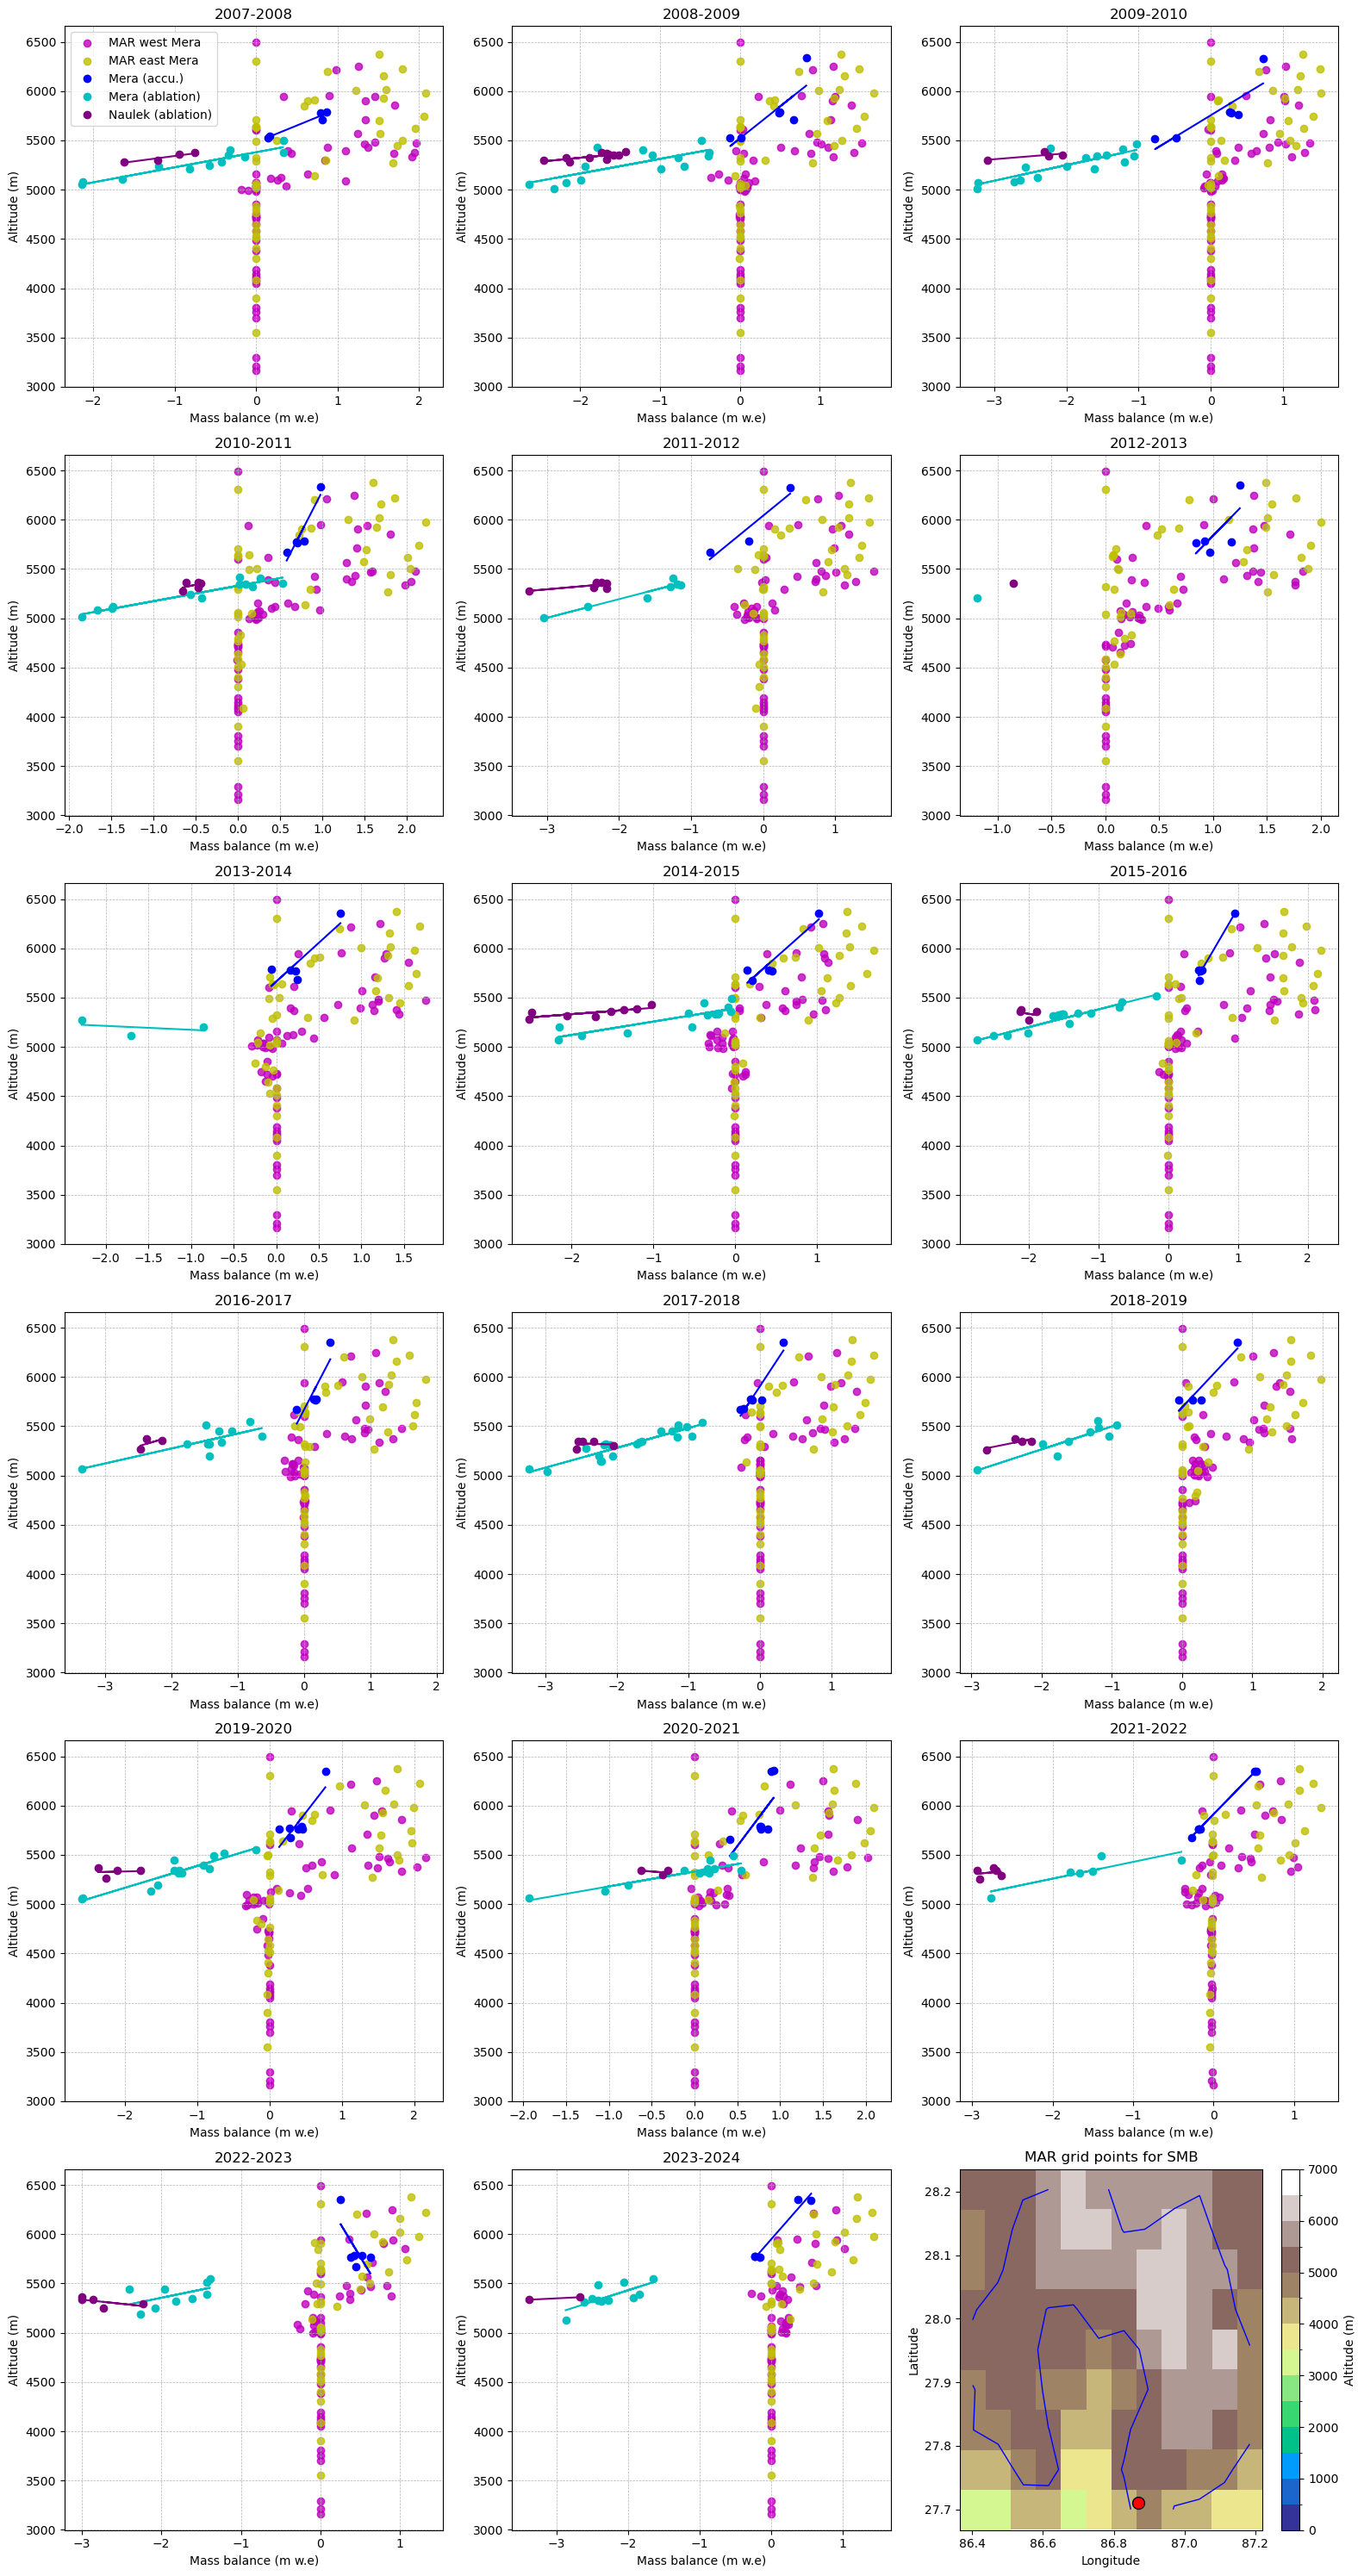

In [42]:
### Khumbu domain east/west

Ydown, Yup, Xleft, Xright = iY, iY+9, iX-7, iX+5 # Choix du maillage en fonction de la position iY et iX de la grille du Mera

col = 3
line = int(np.ceil(nyy/col)) # Arrondi à l'entier supérieur le nombre de colonne à plot, et le met au format 'nombre entier'
fig, axes = plt.subplots(line,col,figsize=(16,5*line))
axes = axes.flatten() # Transforme le tableau 2D en tableau 1D (accessible avec 1 indice (j))

SMB_khumbu_west = []
SMB_khumbu_east = []

####### Grid on last subplot ######
ax = axes[nyy]

plt.contour(ds_lon_khumbu, ds_lat_khumbu, ds_ICE_khumbu, levels=[ice_level], colors="b", linewidths=1) # Contours glaciers
ax.plot(merap_lon, merap_lat, marker='o', markersize=10, markeredgecolor='black', markerfacecolor='red') # Mera peak

pcm = ax.pcolormesh(ds_lon_khumbu, ds_lat_khumbu, ds_SH_khumbu, cmap=cmap, norm=norm, shading='auto')
fig.colorbar(pcm, ax=ax, label="Altitude (m)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("MAR grid points for SMB")


###### Subplot filling ######
for j in range(nyy):
    ax = axes[j] # Remplissage subplot avec indice de la boucle

    ###### MAR_data loading and sorting  ######    
    SMB_day_khumbu = SMB_year[j].sel(TIME=slice(date_ref[j], date_obs[j])).isel(Y=slice(Ydown, Yup), X=slice(Xleft, Xright)) # Valeurs du SMB entre les deux dates de mesures (glacioclim)
    SMB_sum_khumbu = SMB_day_khumbu.sum(dim='TIME')/1000 # Somme l'entièreté de ces valeurs sur la période, et rapporte les millimètres en mètres
    SMB_MAR_khumbu = SMB_sum_khumbu.values.flatten() 

    SH_MAR_khumbu = ds_SH.isel(y=slice(Ydown, Yup), x=slice(Xleft, Xright)).values.flatten() # Altitude des grilles de MAR

    lon_sep = ds_lon_khumbu.values.flatten() 
    # Séparation en deux catégories les sorties de MAR en fonction de leur position par rapport au point de grille du Mera 
    west = lon_sep < merap_lon
    east = lon_sep >= merap_lon
    
    SMB_west = np.mean(SMB_MAR_khumbu[(west) & (SMB_MAR_khumbu != 0)])
    SMB_east = np.mean(SMB_MAR_khumbu[(east) & (SMB_MAR_khumbu != 0)])
    SMB_khumbu_west.append(SMB_west)
    SMB_khumbu_east.append(SMB_east)
    
    # plot de la partie ouest et est des sorties MAR
    ax.scatter(SMB_MAR_khumbu[west], SH_MAR_khumbu[west], color="m", label="MAR west Mera", alpha=0.8)
    ax.scatter(SMB_MAR_khumbu[east], SH_MAR_khumbu[east], color="y", label="MAR east Mera", alpha=0.8)
    
    ###### Plot OBSERVATIONS ######
    ###### Accumulation
    ax.plot(SMB_accu_m[j], SH_accu_m[j], linestyle="", marker="o", color='b', label='Mera (accu.)') # Mera accu
    ax.plot(SMB_accu_m[j], reg_accu_m[j].intercept + reg_accu_m[j].slope * SMB_accu_m[j], 'b') # Mera accu regression lineaire

    ###### Ablation
    ax.plot(SMB_ablation_m[j], SH_ablation_m[j], linestyle="", marker="o", color='c', label='Mera (ablation)') # Mera ablation
    ax.plot(SMB_ablation_m[j], reg_ablation_m[j].intercept + reg_ablation_m[j].slope * SMB_ablation_m[j], 'c') # Mera ablation regression
    ax.plot(SMB_ablation_n[j], SH_ablation_n[j], linestyle="", marker="o", color='purple', label='Naulek (ablation)') # Naulek ablation
    ax.plot(SMB_ablation_n[j], reg_ablation_n[j].intercept + reg_ablation_n[j].slope * SMB_ablation_n[j], 'purple') # Naulek ablation regression
    
    ###### Graphic features ######
    ax.set_title(f"20{yy[j]}-20{yy[j+1]}")
    ax.set_xlabel("Mass balance (m w.e)")
    ax.set_ylabel("Altitude (m)")
    ax.grid(linestyle = '--', linewidth = 0.5)
    
    if j == 0: # Affiche la légende pour la première figure
        ax.legend()

plt.tight_layout()

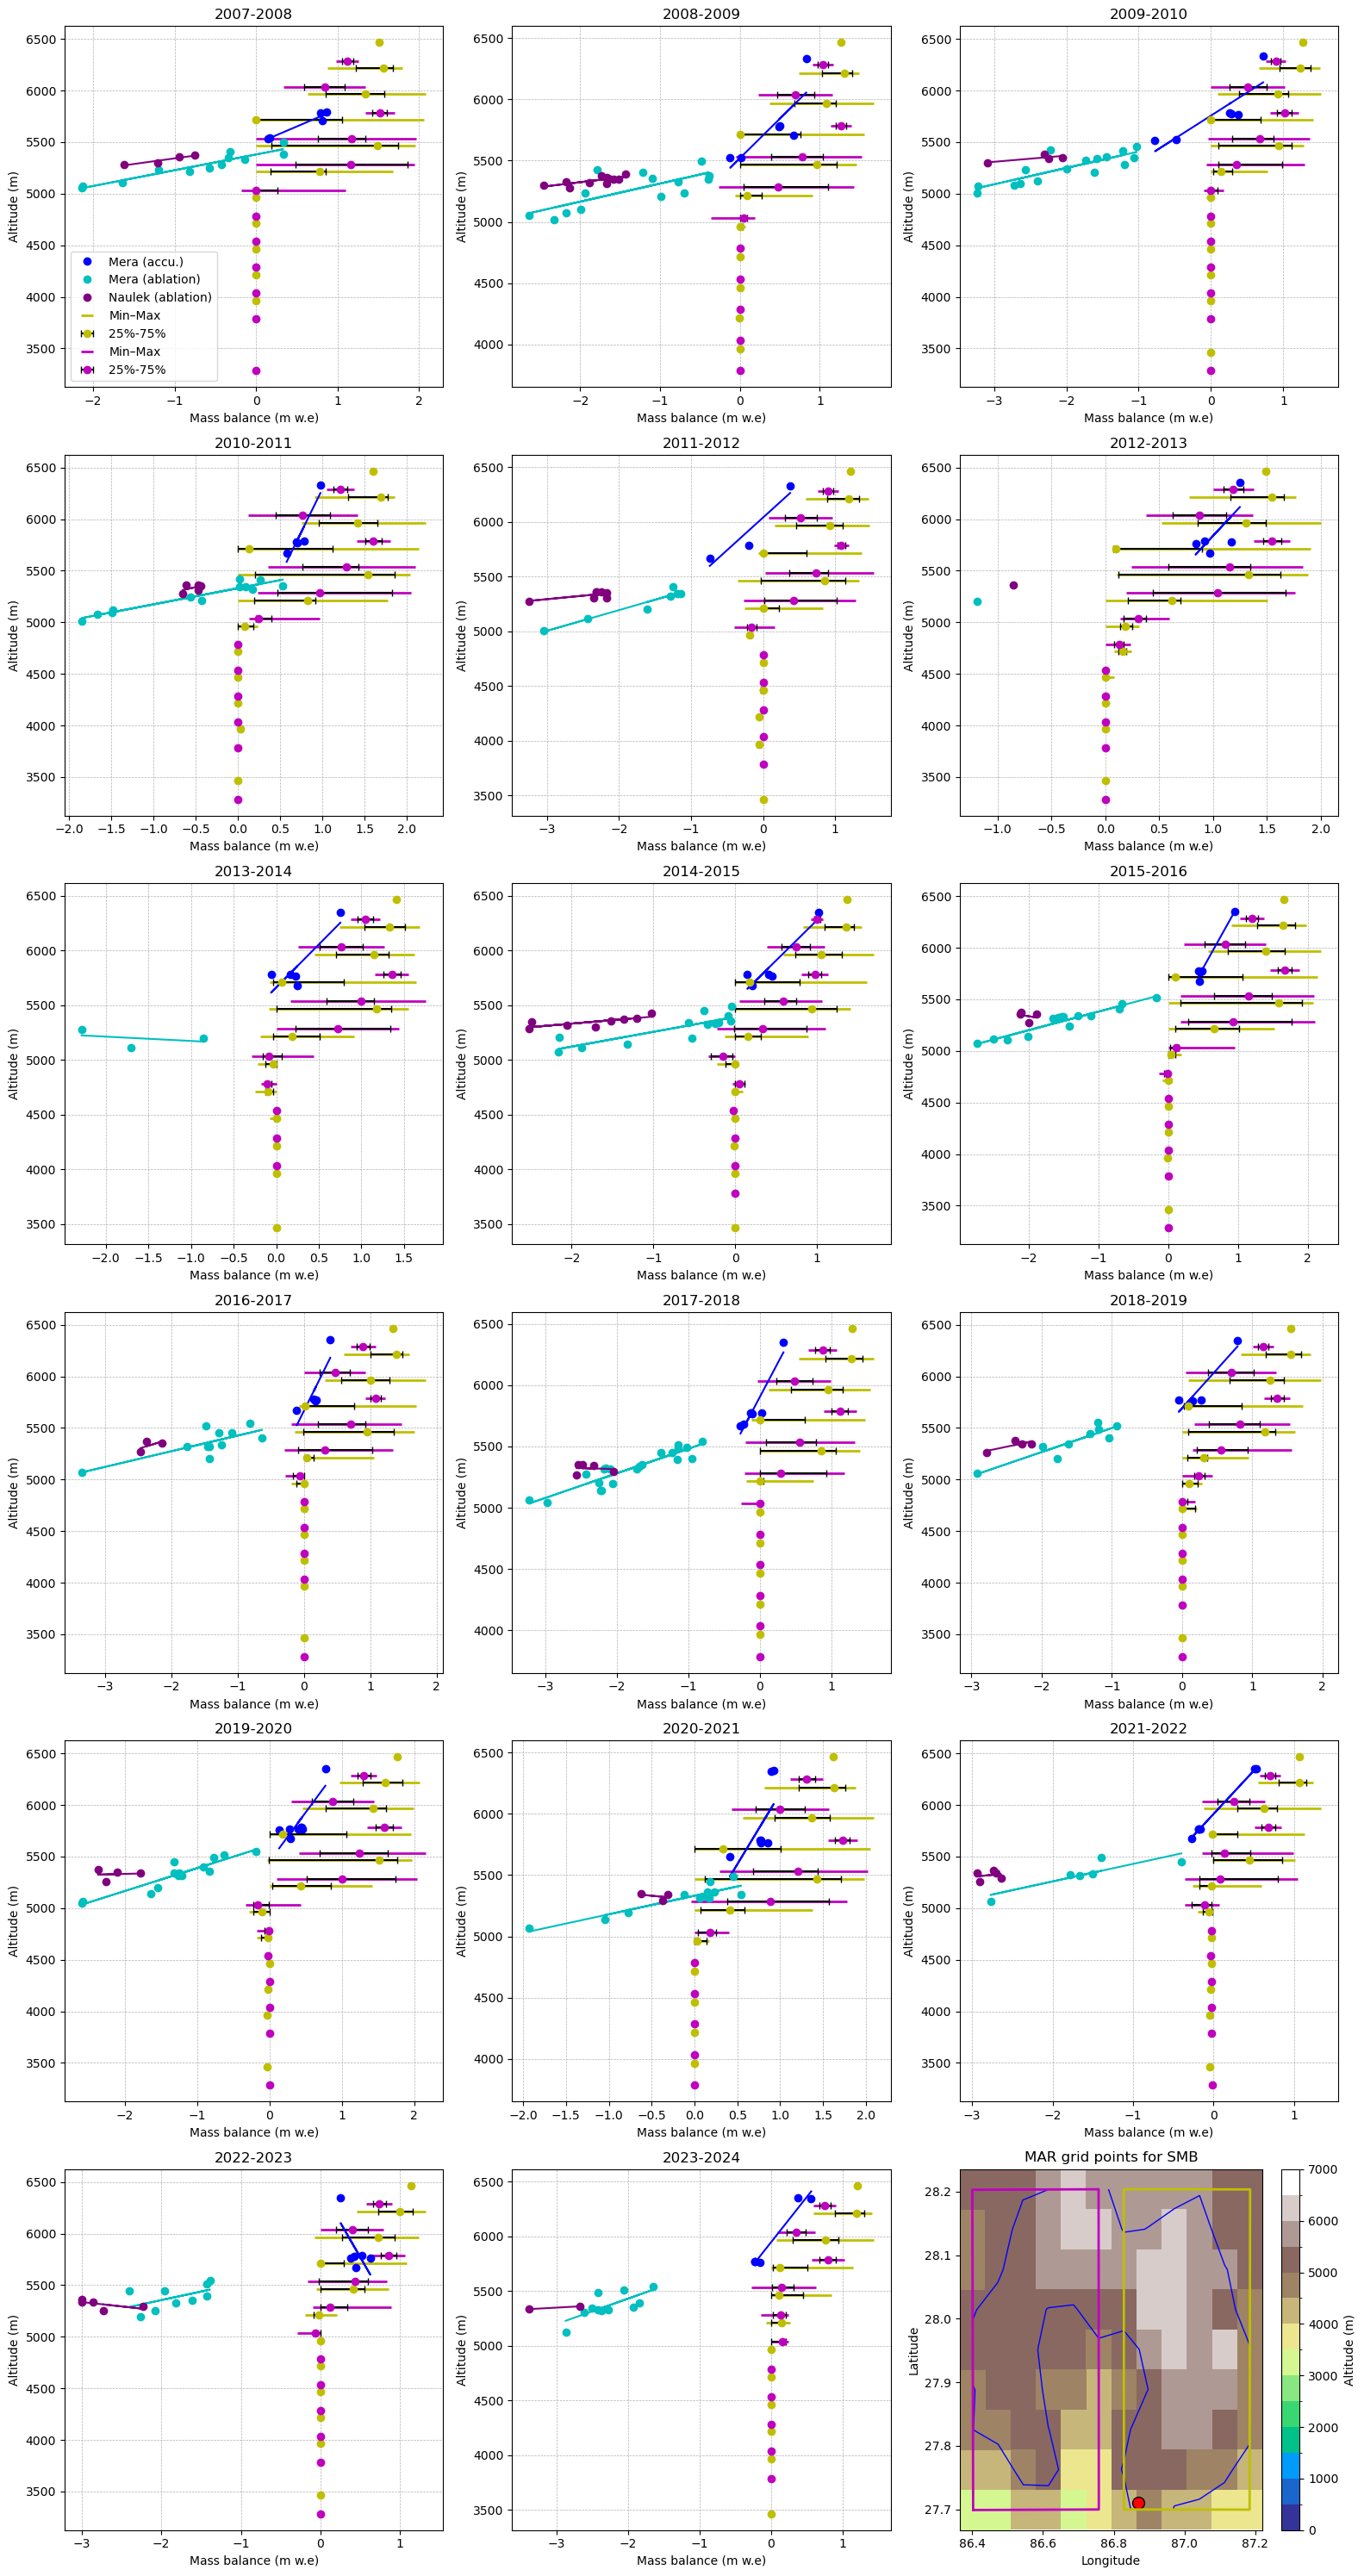

In [43]:
### Khumbu east/west alt band

Ydown, Yup, Xleft, Xright = iY, iY+9, iX-7, iX+5 # Choix du maillage en fonction de la position iY et iX de la grille du Mera

col = 3
line = int(np.ceil(nyy/col)) # Arrondi à l'entier supérieur le nombre de colonne à plot, et le met au format 'nombre entier'
fig, axes = plt.subplots(line,col,figsize=(16,5*line))
axes = axes.flatten() # Transforme le tableau 2D en tableau 1D (accessible avec 1 indice (j))


####### Grid on last subplot ######
ax = axes[nyy]

plt.contour(ds_lon_khumbu, ds_lat_khumbu, ds_ICE_khumbu, levels=[ice_level], colors="b", linewidths=1) # Contours glaciers
ax.plot(merap_lon, merap_lat, marker='o', markersize=10, markeredgecolor='black', markerfacecolor='red') # Mera peak

pcm = ax.pcolormesh(ds_lon_khumbu, ds_lat_khumbu, ds_SH_khumbu, cmap=cmap, norm=norm, shading='auto')
fig.colorbar(pcm, ax=ax, label="Altitude (m)")

# Ici on définit des slices sans passer par iY et iX car on a déjà découpé le domaine sur le khumbu
# On cherche des zones dans le khumbu à partir du bas gauche du domaine (sous la forme slice(y,y),slice(x,x) --> Point en bas à gauche est (0,0)
# orange=everest / rouge=procheMera / magenta= NordOuest
subdom = [(slice(0,9), slice(6,12), "y"), (slice(0,9), slice(0,6),"m")]

for ys, xs, color in subdom: # On a un tuple, le nom des variable n'a pas d'importance tant que l'ordre est respecté
    lat_sub = ds_lat_khumbu.isel(y=ys, x=xs).values
    lon_sub = ds_lon_khumbu.isel(y=ys, x=xs).values

    rect_lat = [lat_sub[0,0], lat_sub[0,-1], lat_sub[-1,-1], lat_sub[-1,0], lat_sub[0,0]] # Selection des angles des sous domaines
    rect_lon = [lon_sub[0,0], lon_sub[0,-1], lon_sub[-1,-1], lon_sub[-1,0], lon_sub[0,0]]
    
    ax.plot(rect_lon, rect_lat, color=color, linewidth=2)
    
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("MAR grid points for SMB")


###### Subplot filling ######
for j in range(nyy):
    ax = axes[j] # Remplissage subplot avec indice de la boucle

    ###### MAR_data loading and sorting  ######    
    SMB_day_khumbu = SMB_year[j].sel(TIME=slice(date_ref[j], date_obs[j])).isel(Y=slice(Ydown, Yup), X=slice(Xleft, Xright)) # Valeurs du SMB entre les deux dates de mesures (glacioclim)
    SMB_sum_khumbu = SMB_day_khumbu.sum(dim='TIME')/1000 # Somme l'entièreté de ces valeurs sur la période, et rapporte les millimètres en mètres
    SMB_MAR_khumbu = SMB_sum_khumbu.values.flatten() 

    SH_MAR_khumbu = ds_SH.isel(y=slice(Ydown, Yup), x=slice(Xleft, Xright)).values.flatten() # Altitude des grilles de MAR

    for ys, xs, color in subdom: # On a un tuple, le nom des variable n'a pas d'importance tant que l'ordre est respecté

        SMB_subdom = SMB_sum_khumbu.isel(Y=ys, X=xs).values.flatten()
        SH_subdom  = ds_SH_khumbu.isel(y=ys, x=xs).values.flatten()

        #ax.scatter(SMB_subdom, SH_subdom, color=color, label='MAR')
    
        #### Création des classes d'altitude (pas de 250 m)
        alt_band = np.arange(125, 7000, 250)
        alt_classes = np.digitize(SH_subdom, alt_band) # Digitize permet de mettre dans les classes d'altitude les différentes grilles selon leur altitudes sous forme de liste [1,2,2,1,3,2]

        SMB_min, SMB_max, SMB_p50, SMB_p25, SMB_p75, alt_center = [], [], [], [], [], [] # Définition des listes des percentilles, min et max de chaque classe d'alt

        for a in np.unique(alt_classes): # Comme alt_classes est une liste donnant un indice à chaque point de grille en fonction de l'altitude. np.unique ne regarde qu'une fois un indice déjà vu
            # Création d'un mask "m" qui va prendre la forme m = [False, True, True, False...] avec une condition sur si la classe et sur si la valeur de SMB n'est pas nulle
            m = (alt_classes == a) & (SMB_subdom != 0) 

            smbk = SMB_subdom[m]
            shk = SH_subdom[m]

            if len(smbk) == 0:   # Si la liste smbk pour une classe d'alt est vide (cad que tous les smb pour cette alt sont nuls), on passe à l'itération suivante pour éviter un bug dans la boucle
                continue

            p25 = np.percentile(smbk, 25)
            p50 = np.percentile(smbk, 50)   # médiane
            p75 = np.percentile(smbk, 75)
        
            # Grâce au mask, on peut alors faire des opérations sur les variables restreintes aux bandes d'altitudes
            SMB_p25.append(p25)
            SMB_p50.append(p50)
            SMB_p75.append(p75)
            SMB_min.append(np.min(smbk))
            SMB_max.append(np.max(smbk))
        
            #alt_center.append(np.mean(shk))
            alt_center.append(alt_band[a-1] + 125) # Affiche simplement le centre de la bande sans moyenner ("a-1" car digitize a un indice qui commence par 1)

        SMB_p25 = np.array(SMB_p25) # Transformation des listes en tableaux pour pouvoir les plot
        SMB_p50 = np.array(SMB_p50)
        SMB_p75 = np.array(SMB_p75)
        SMB_min = np.array(SMB_min)
        SMB_max = np.array(SMB_max)
        alt_center = np.array(alt_center)

        offset = {"y": -35, "m": 35} # Rajoute un leger offset de en altitude pour ne pas supperposer les valeurs

        # Plot de la barre d'erreur avec xerr qui affiche une barre de couleur "ecolor", et de taille "capsize"
        ax.errorbar(SMB_p50, alt_center + offset[color], xerr=[SMB_p50-SMB_min, SMB_max-SMB_p50], fmt="none", ecolor=color, elinewidth=2, alpha=1, label="Min–Max")
        ax.errorbar(SMB_p50, alt_center + offset[color], xerr=[SMB_p50-SMB_p25, SMB_p75-SMB_p50], fmt="o", color=color, ecolor='k', elinewidth=1.5, capsize=3, label="25%-75%")

    ###### Plot OBSERVATIONS ######
    ###### Accumulation
    ax.plot(SMB_accu_m[j], SH_accu_m[j], linestyle="", marker="o", color='b', label='Mera (accu.)') # Mera accu
    ax.plot(SMB_accu_m[j], reg_accu_m[j].intercept + reg_accu_m[j].slope * SMB_accu_m[j], 'b') # Mera accu regression lineaire

    ###### Ablation
    ax.plot(SMB_ablation_m[j], SH_ablation_m[j], linestyle="", marker="o", color='c', label='Mera (ablation)') # Mera ablation
    ax.plot(SMB_ablation_m[j], reg_ablation_m[j].intercept + reg_ablation_m[j].slope * SMB_ablation_m[j], 'c') # Mera ablation regression
    ax.plot(SMB_ablation_n[j], SH_ablation_n[j], linestyle="", marker="o", color='purple', label='Naulek (ablation)') # Naulek ablation
    ax.plot(SMB_ablation_n[j], reg_ablation_n[j].intercept + reg_ablation_n[j].slope * SMB_ablation_n[j], 'purple') # Naulek ablation regression
    
    ###### Graphic features ######
    ax.set_title(f"20{yy[j]}-20{yy[j+1]}")
    ax.set_xlabel("Mass balance (m w.e)")
    ax.set_ylabel("Altitude (m)")
    ax.grid(linestyle = '--', linewidth = 0.5)
    
    if j == 0: # Affiche la légende pour la première figure
        ax.legend()

plt.tight_layout()

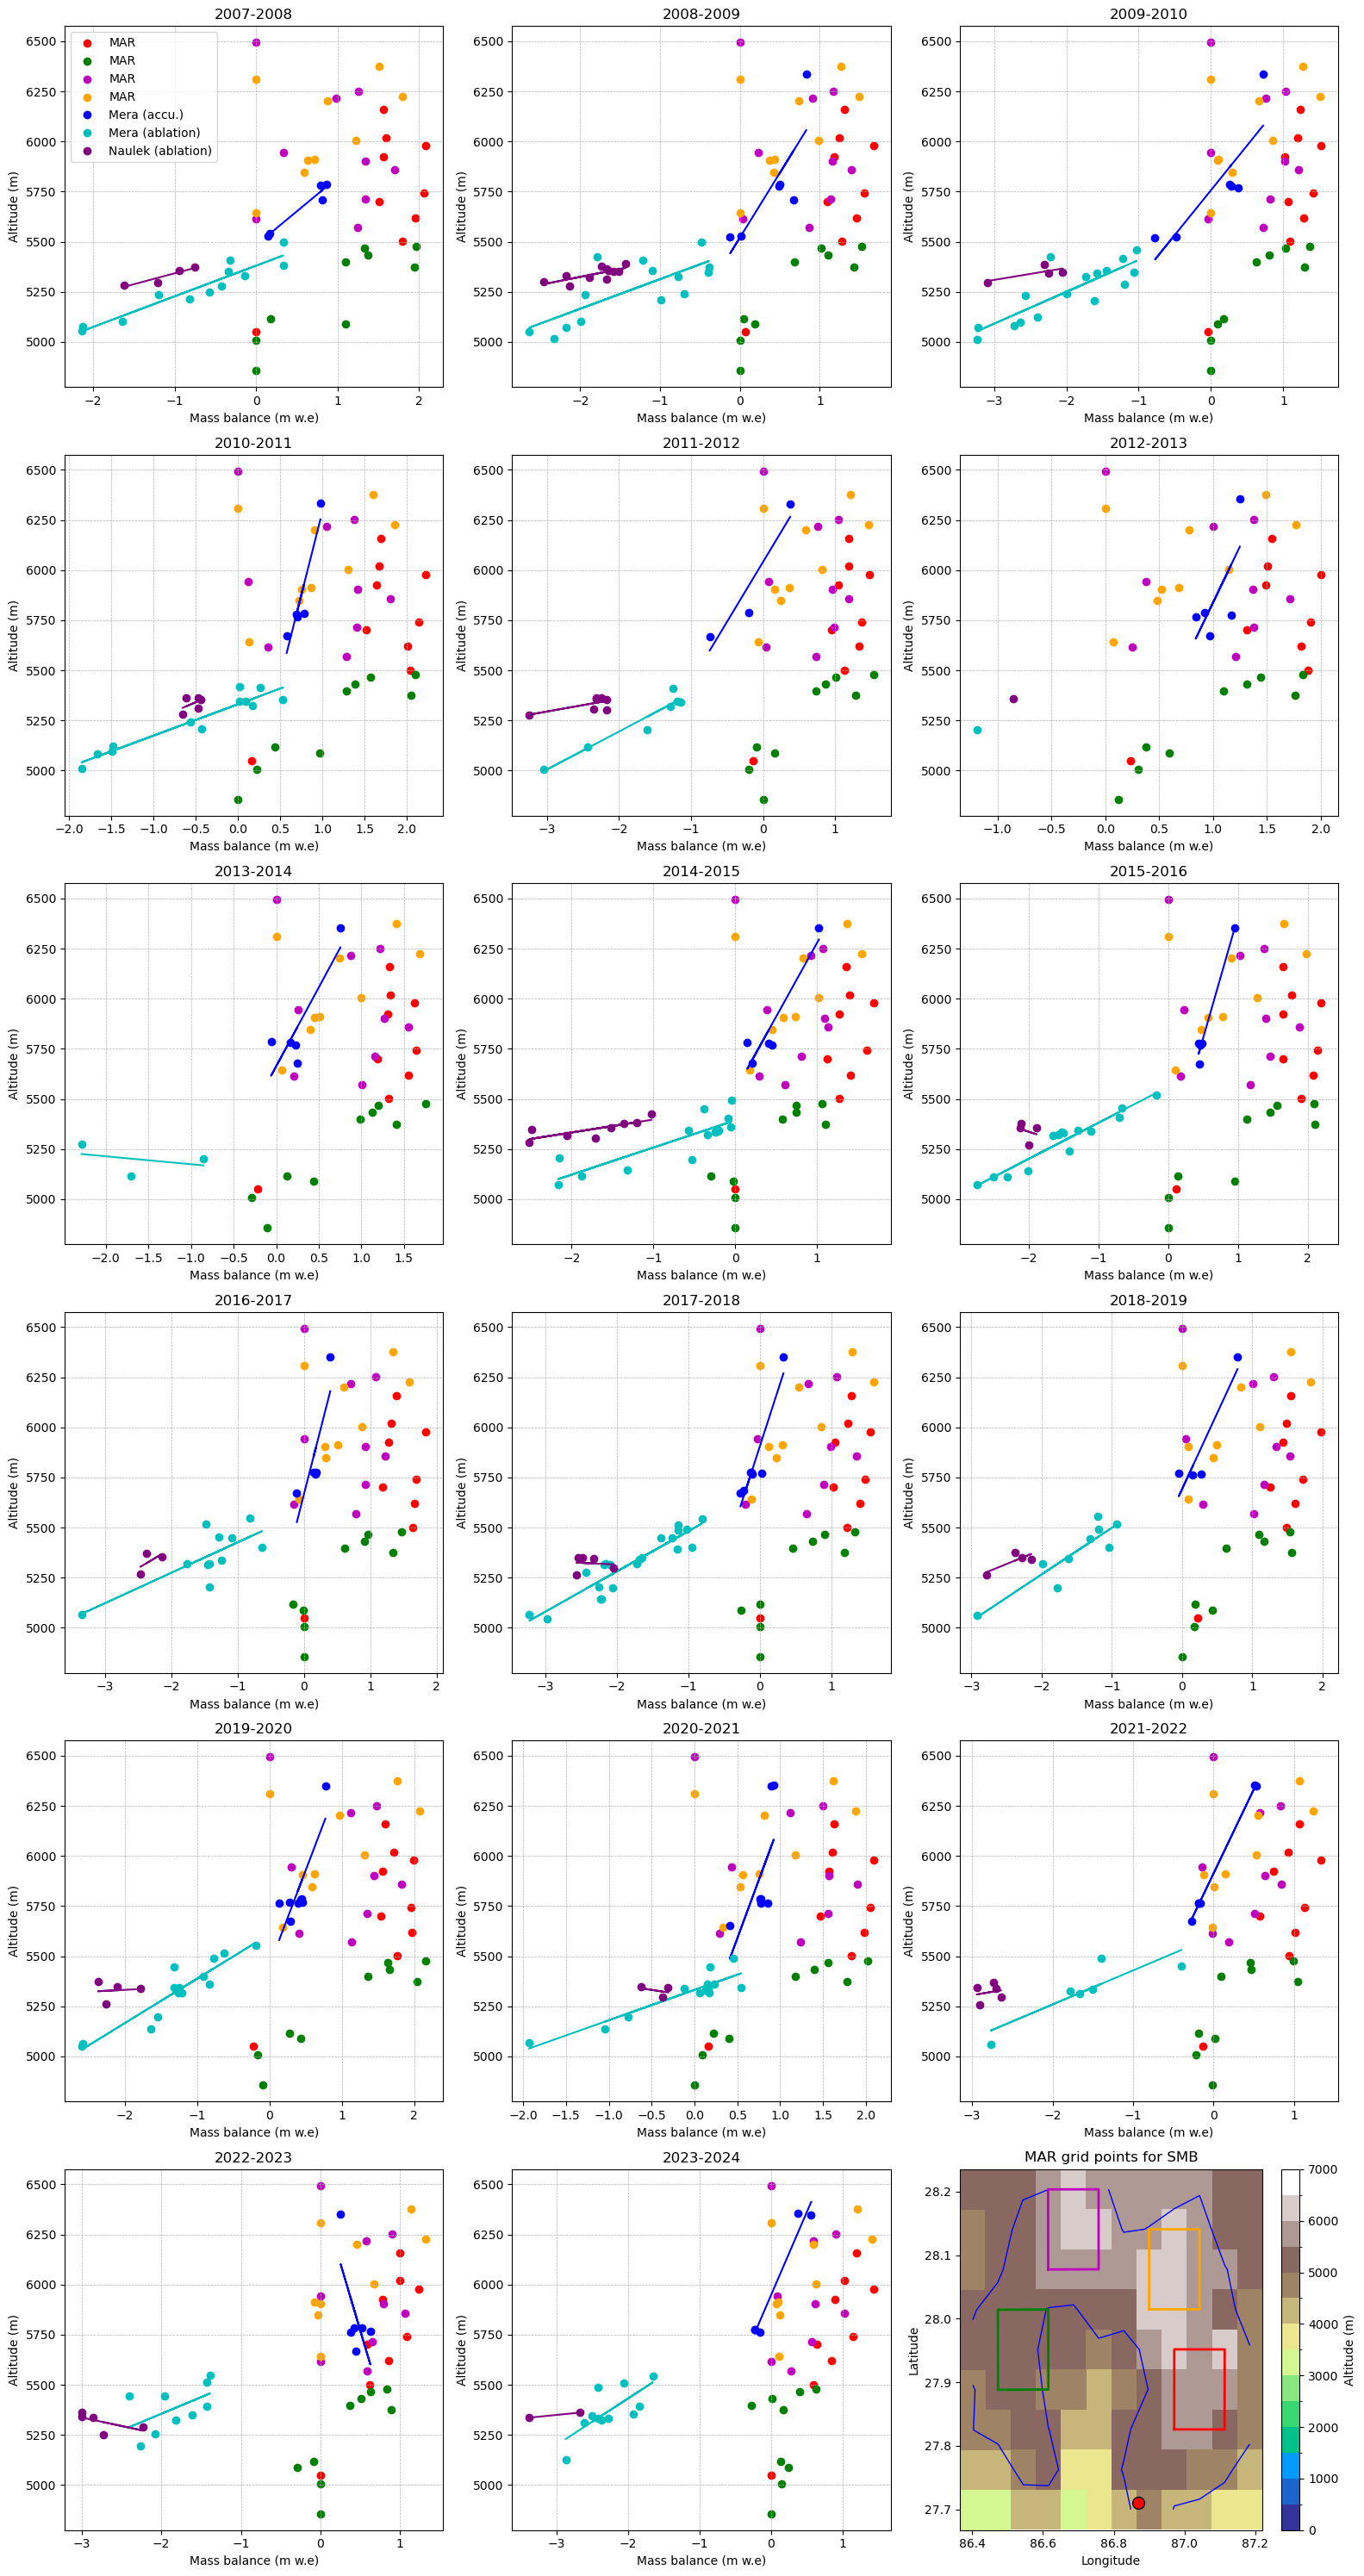

In [44]:
### Khumbu split in 4 domains

Ydown, Yup, Xleft, Xright = iY, iY+9, iX-7, iX+5 # Choix du maillage en fonction de la position iY et iX de la grille du Mera

col = 3
line = int(np.ceil(nyy/col)) # Arrondi à l'entier supérieur le nombre de colonne à plot, et le met au format 'nombre entier'
fig, axes = plt.subplots(line,col,figsize=(16,5*line))
axes = axes.flatten() # Transforme le tableau 2D en tableau 1D (accessible avec 1 indice (j))

SMB_khumbu = {"r": [], "g": [], "m": [], "orange": []} # Création d'un dictionnaire pour gérer les sous domaines par couleurs

####### Grid on last subplot ######
ax = axes[nyy]

plt.contour(ds_lon_khumbu, ds_lat_khumbu, ds_ICE_khumbu, levels=[ice_level], colors="b", linewidths=1) # Contours glaciers
ax.plot(merap_lon, merap_lat, marker='o', markersize=10, markeredgecolor='black', markerfacecolor='red') # Mera peak

pcm = ax.pcolormesh(ds_lon_khumbu, ds_lat_khumbu, ds_SH_khumbu, cmap=cmap, norm=norm, shading='auto')
fig.colorbar(pcm, ax=ax, label="Altitude (m)")

# Ici on définit des slices sans passer par iY et iX car on a déjà découpé le domaine sur le khumbu
# On cherche des zones dans le khumbu à partir du bas gauche du domaine (sous la forme slice(y,y),slice(x,x) --> Point en bas à gauche est (0,0)
# orange=everest / rouge=procheMera / magenta= NordOuest
subdom = [(slice(2,5), slice(8,11), "r"), (slice(3,6), slice(1,4),"g"), (slice(6,9), slice(3,6), "m"), (slice(5,8), slice(7,10), "orange")]

for ys, xs, color in subdom: # On a un tuple, le nom des variable n'a pas d'importance tant que l'ordre est respecté
    lat_sub = ds_lat_khumbu.isel(y=ys, x=xs).values
    lon_sub = ds_lon_khumbu.isel(y=ys, x=xs).values

    rect_lat = [lat_sub[0,0], lat_sub[0,-1], lat_sub[-1,-1], lat_sub[-1,0], lat_sub[0,0]] # Selection des angles des sous domaines
    rect_lon = [lon_sub[0,0], lon_sub[0,-1], lon_sub[-1,-1], lon_sub[-1,0], lon_sub[0,0]]
    
    ax.plot(rect_lon, rect_lat, color=color, linewidth=2)
    
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("MAR grid points for SMB")


###### Subplot filling ######
for j in range(nyy):
    ax = axes[j] # Remplissage subplot avec indice de la boucle

    ###### MAR_data loading and sorting  ######    
    SMB_day_khumbu = SMB_year[j].sel(TIME=slice(date_ref[j], date_obs[j])).isel(Y=slice(Ydown, Yup), X=slice(Xleft, Xright)) # Valeurs du SMB entre les deux dates de mesures (glacioclim)
    SMB_sum_khumbu = SMB_day_khumbu.sum(dim='TIME')/1000 # Somme l'entièreté de ces valeurs sur la période, et rapporte les millimètres en mètres

    for ys, xs, color in subdom: # On a un tuple, le nom des variable n'a pas d'importance tant que l'ordre est respecté

        SMB_subdom = SMB_sum_khumbu.isel(Y=ys, X=xs).values.flatten()
        SH_subdom  = ds_SH_khumbu.isel(y=ys, x=xs).values.flatten()

        # Préparation des listes pour plot séries temporelles
        smbk = SMB_subdom[SMB_subdom != 0] # Exclusion des SMB égales à zéro
        SMB_khumbu[color].append(np.mean(smbk)) # Ajout de la moyenne du sous domaine par année

        ax.scatter(SMB_subdom, SH_subdom, color=color, label='MAR')
    
    ###### Plot OBSERVATIONS ######
    ###### Accumulation
    ax.plot(SMB_accu_m[j], SH_accu_m[j], linestyle="", marker="o", color='b', label='Mera (accu.)') # Mera accu
    ax.plot(SMB_accu_m[j], reg_accu_m[j].intercept + reg_accu_m[j].slope * SMB_accu_m[j], 'b') # Mera accu regression lineaire

    ###### Ablation
    ax.plot(SMB_ablation_m[j], SH_ablation_m[j], linestyle="", marker="o", color='c', label='Mera (ablation)') # Mera ablation
    ax.plot(SMB_ablation_m[j], reg_ablation_m[j].intercept + reg_ablation_m[j].slope * SMB_ablation_m[j], 'c') # Mera ablation regression
    ax.plot(SMB_ablation_n[j], SH_ablation_n[j], linestyle="", marker="o", color='purple', label='Naulek (ablation)') # Naulek ablation
    ax.plot(SMB_ablation_n[j], reg_ablation_n[j].intercept + reg_ablation_n[j].slope * SMB_ablation_n[j], 'purple') # Naulek ablation regression
    
    ###### Graphic features ######
    ax.set_title(f"20{yy[j]}-20{yy[j+1]}")
    ax.set_xlabel("Mass balance (m w.e)")
    ax.set_ylabel("Altitude (m)")
    ax.grid(linestyle = '--', linewidth = 0.5)
    
    if j == 0: # Affiche la légende pour la première figure
        ax.legend()

plt.tight_layout()

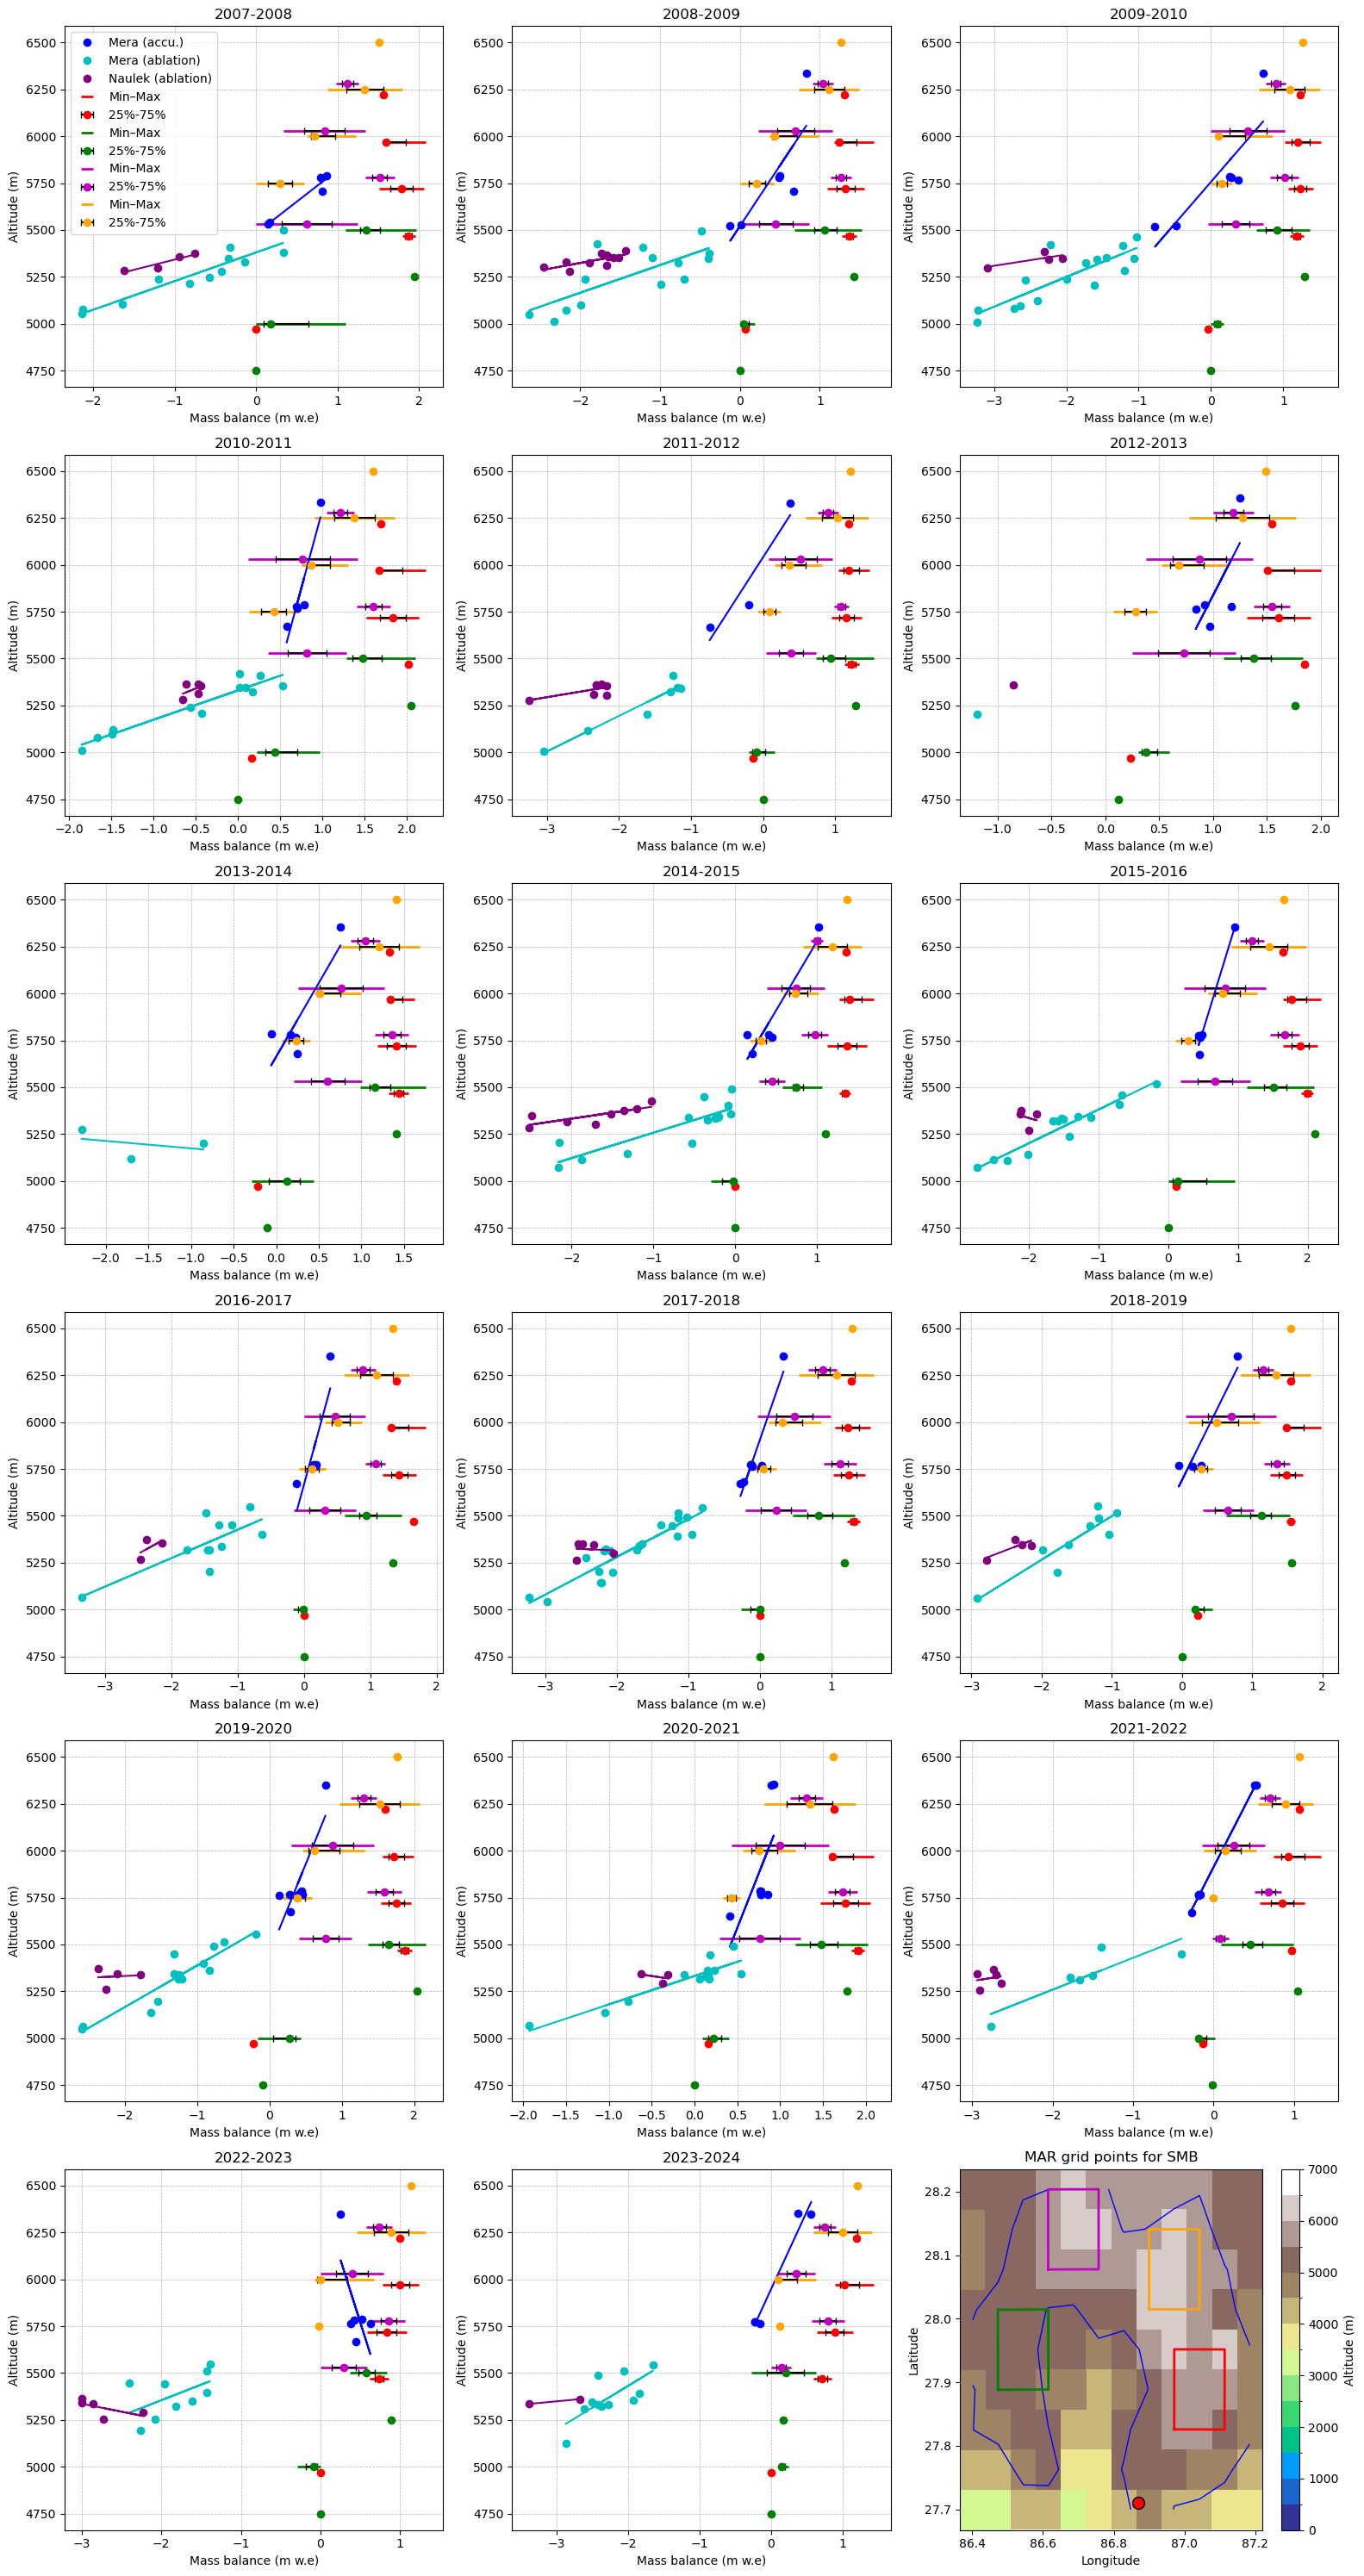

In [45]:
### Khumbu alt band split in 4 domains

Ydown, Yup, Xleft, Xright = iY, iY+9, iX-7, iX+5 # Choix du maillage en fonction de la position iY et iX de la grille du Mera

col = 3
line = int(np.ceil(nyy/col)) # Arrondi à l'entier supérieur le nombre de colonne à plot, et le met au format 'nombre entier'
fig, axes = plt.subplots(line,col,figsize=(16,5*line))
axes = axes.flatten() # Transforme le tableau 2D en tableau 1D (accessible avec 1 indice (j))


####### Grid on last subplot ######
ax = axes[nyy]

plt.contour(ds_lon_khumbu, ds_lat_khumbu, ds_ICE_khumbu, levels=[ice_level], colors="b", linewidths=1) # Contours glaciers
ax.plot(merap_lon, merap_lat, marker='o', markersize=10, markeredgecolor='black', markerfacecolor='red') # Mera peak

pcm = ax.pcolormesh(ds_lon_khumbu, ds_lat_khumbu, ds_SH_khumbu, cmap=cmap, norm=norm, shading='auto')
fig.colorbar(pcm, ax=ax, label="Altitude (m)")

# Ici on définit des slices sans passer par iY et iX car on a déjà découpé le domaine sur le khumbu
# On cherche des zones dans le khumbu à partir du bas gauche du domaine (sous la forme slice(y,y),slice(x,x) --> Point en bas à gauche est (0,0)
# orange=everest / rouge=procheMera / magenta= NordOuest
subdom = [(slice(2,5), slice(8,11), "r"), (slice(3,6), slice(1,4),"g"), (slice(6,9), slice(3,6), "m"), (slice(5,8), slice(7,10), "orange")]

for ys, xs, color in subdom: # On a un tuple, le nom des variable n'a pas d'importance tant que l'ordre est respecté
    lat_sub = ds_lat_khumbu.isel(y=ys, x=xs).values
    lon_sub = ds_lon_khumbu.isel(y=ys, x=xs).values

    rect_lat = [lat_sub[0,0], lat_sub[0,-1], lat_sub[-1,-1], lat_sub[-1,0], lat_sub[0,0]] # Selection des angles des sous domaines
    rect_lon = [lon_sub[0,0], lon_sub[0,-1], lon_sub[-1,-1], lon_sub[-1,0], lon_sub[0,0]]
    
    ax.plot(rect_lon, rect_lat, color=color, linewidth=2)
    
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("MAR grid points for SMB")


###### Subplot filling ######
for j in range(nyy):
    ax = axes[j] # Remplissage subplot avec indice de la boucle

    ###### MAR_data loading and sorting  ######    
    SMB_day_khumbu = SMB_year[j].sel(TIME=slice(date_ref[j], date_obs[j])).isel(Y=slice(Ydown, Yup), X=slice(Xleft, Xright)) # Valeurs du SMB entre les deux dates de mesures (glacioclim)
    SMB_sum_khumbu = SMB_day_khumbu.sum(dim='TIME')/1000 # Somme l'entièreté de ces valeurs sur la période, et rapporte les millimètres en mètres
    SMB_MAR_khumbu = SMB_sum_khumbu.values.flatten() 

    SH_MAR_khumbu = ds_SH.isel(y=slice(Ydown, Yup), x=slice(Xleft, Xright)).values.flatten() # Altitude des grilles de MAR

    for ys, xs, color in subdom: # On a un tuple, le nom des variable n'a pas d'importance tant que l'ordre est respecté

        SMB_subdom = SMB_sum_khumbu.isel(Y=ys, X=xs).values.flatten()
        SH_subdom  = ds_SH_khumbu.isel(y=ys, x=xs).values.flatten()

        #ax.scatter(SMB_subdom, SH_subdom, color=color, label='MAR')
    
        #### Création des classes d'altitude (pas de 250 m)
        alt_band = np.arange(125, 7000, 250)
        alt_classes = np.digitize(SH_subdom, alt_band) # Digitize permet de mettre dans les classes d'altitude les différentes grilles selon leur altitudes sous forme de liste [1,2,2,1,3,2]

        SMB_min, SMB_max, SMB_p50, SMB_p25, SMB_p75, alt_center = [], [], [], [], [], [] # Définition des listes des percentilles, min et max de chaque classe d'alt

        for a in np.unique(alt_classes): # Comme alt_classes est une liste donnant un indice à chaque point de grille en fonction de l'altitude. np.unique ne regarde qu'une fois un indice déjà vu
            # Création d'un mask "m" qui va prendre la forme m = [False, True, True, False...] avec une condition sur si la classe et sur si la valeur de SMB n'est pas nulle
            m = (alt_classes == a) & (SMB_subdom != 0) 

            smbk = SMB_subdom[m]
            shk = SH_subdom[m]

            if len(smbk) == 0:   # Si la liste smbk pour une classe d'alt est vide (cad que tous les smb pour cette alt sont nuls), on passe à l'itération suivante pour éviter un bug dans la boucle
                continue

            p25 = np.percentile(smbk, 25)
            p50 = np.percentile(smbk, 50)   # médiane
            p75 = np.percentile(smbk, 75)
        
            # Grâce au mask, on peut alors faire des opérations sur les variables restreintes aux bandes d'altitudes
            SMB_p25.append(p25)
            SMB_p50.append(p50)
            SMB_p75.append(p75)
            SMB_min.append(np.min(smbk))
            SMB_max.append(np.max(smbk))
        
            #alt_center.append(np.mean(shk))
            alt_center.append(alt_band[a-1] + 125) # Affiche simplement le centre de la bande sans moyenner ("a-1" car digitize a un indice qui commence par 1)

        SMB_p25 = np.array(SMB_p25) # Transformation des listes en tableaux pour pouvoir les plot
        SMB_p50 = np.array(SMB_p50)
        SMB_p75 = np.array(SMB_p75)
        SMB_min = np.array(SMB_min)
        SMB_max = np.array(SMB_max)
        alt_center = np.array(alt_center)

        offset = {"r": -30, "orange": 0, "g": 0, "m": 30} # Rajoute un leger offset de en altitude pour ne pas supperposer les valeurs

        # Plot de la barre d'erreur avec xerr qui affiche une barre de couleur "ecolor", et de taille "capsize"
        ax.errorbar(SMB_p50, alt_center + offset[color], xerr=[SMB_p50-SMB_min, SMB_max-SMB_p50], fmt="none", ecolor=color, elinewidth=2, alpha=1, label="Min–Max")
        ax.errorbar(SMB_p50, alt_center + offset[color], xerr=[SMB_p50-SMB_p25, SMB_p75-SMB_p50], fmt="o", color=color, ecolor='k', elinewidth=1.5, capsize=3, label="25%-75%")

    ###### Plot OBSERVATIONS ######
    ###### Accumulation
    ax.plot(SMB_accu_m[j], SH_accu_m[j], linestyle="", marker="o", color='b', label='Mera (accu.)') # Mera accu
    ax.plot(SMB_accu_m[j], reg_accu_m[j].intercept + reg_accu_m[j].slope * SMB_accu_m[j], 'b') # Mera accu regression lineaire

    ###### Ablation
    ax.plot(SMB_ablation_m[j], SH_ablation_m[j], linestyle="", marker="o", color='c', label='Mera (ablation)') # Mera ablation
    ax.plot(SMB_ablation_m[j], reg_ablation_m[j].intercept + reg_ablation_m[j].slope * SMB_ablation_m[j], 'c') # Mera ablation regression
    ax.plot(SMB_ablation_n[j], SH_ablation_n[j], linestyle="", marker="o", color='purple', label='Naulek (ablation)') # Naulek ablation
    ax.plot(SMB_ablation_n[j], reg_ablation_n[j].intercept + reg_ablation_n[j].slope * SMB_ablation_n[j], 'purple') # Naulek ablation regression
    
    ###### Graphic features ######
    ax.set_title(f"20{yy[j]}-20{yy[j+1]}")
    ax.set_xlabel("Mass balance (m w.e)")
    ax.set_ylabel("Altitude (m)")
    ax.grid(linestyle = '--', linewidth = 0.5)
    
    if j == 0: # Affiche la légende pour la première figure
        ax.legend()

plt.tight_layout()

In [46]:
annual_MB = [0.15, -0.35, -0.75, 0.26, -0.90, 0.19, -0.41, -0.22, -0.42, -0.76, -0.92, -0.80, -0.49] # Annual glacier-wide (m w.e.a-1) MB 2007-2020 from Wagnon
error_annual = [0.28, 0.26, 0.24, 0.22, 0.19, 0.16, 0.16, 0.16, 0.16, 0.16, 0.16, 0.19, 0.22]

annual_cum = np.cumsum(annual_MB)

# Remplissage de la liste des années
years = []
for j in range (nyy):
    years.append(int("20"+yy[j+1]))

n = min(len(years), len(annual_MB)) # Permet de plot jusqu'à ce que la plus petite liste soit vidée

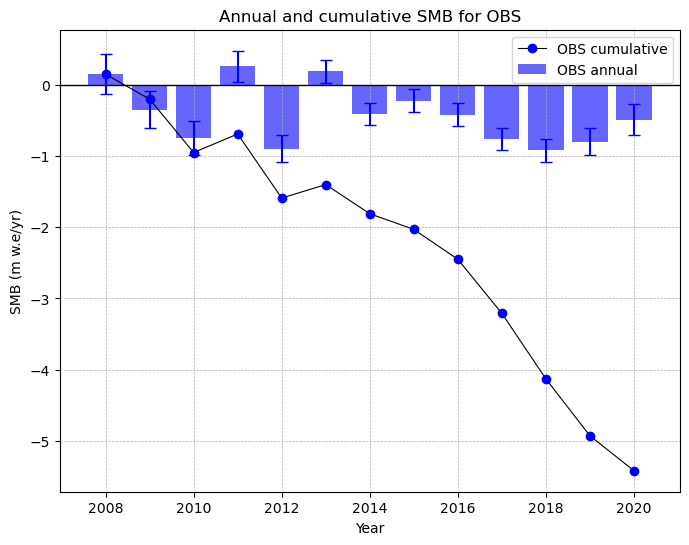

In [47]:
# Série temporelle OBS 
plt.figure(figsize=(8,6))

plt.bar(years[:n], annual_MB[:n], yerr=error_annual[:n], # yerr est une fonction matplotlib qui permt d'afficher les barres d'erreur 
        color="b", alpha=0.6, width=0.8, capsize=4, ecolor="b", label="OBS annual") # SMB OBS annuel sous forme de bar 
plt.plot(years[:n], annual_cum[:n], 
         color="k", linewidth=0.8, marker="o", markerfacecolor="b", markeredgecolor="b", label="OBS cumulative") # Plot jusqu'à ce que la plus petite liste soit vidée

plt.axhline(0, color="k", linewidth=1) # Affiche une ligne à l'horizontal (ici 0)
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(2)) # Force l'espace sur l'axe des x
plt.xlabel("Year")
plt.ylabel("SMB (m w.e/yr)")
plt.title("Annual and cumulative SMB for OBS")
plt.legend()
plt.grid(linestyle = '--', linewidth = 0.5)

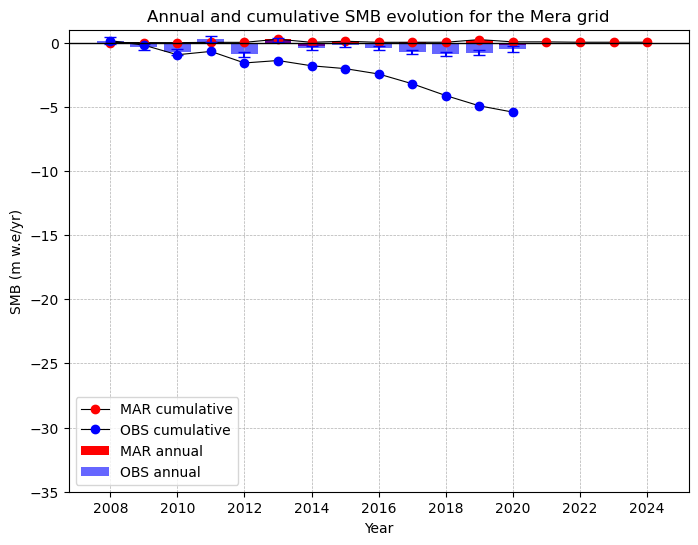

In [48]:
### Série temporelle SMB grille du Mera

plt.figure(figsize=(8,6))

SMB_cum = np.cumsum(SMB_list_Mera)

plt.bar(years, SMB_list_Mera, color="r", alpha=1, width=0.8, label="MAR annual") # SMB MAR annuel sous forme de bar 
plt.plot(years, SMB_cum, color="k", linewidth=0.8, marker="o", markerfacecolor="r", markeredgecolor="r", label="MAR cumulative") # Cumulative SMB

plt.bar(years[:n], annual_MB[:n], yerr=error_annual[:n],
        color="b", alpha=0.6, width=0.8, capsize=4, ecolor="b", label="OBS annual") # SMB OBS annuel sous forme de bar 
plt.plot(years[:n], annual_cum[:n], color="k", linewidth=0.8, marker="o", markerfacecolor="b", markeredgecolor="b", label="OBS cumulative") # Plot jusqu'à ce que la plus petite liste soit vidée

plt.axhline(0, color="k", linewidth=1) # Affiche une ligne à l'horizontal (ici 0)
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(2)) # Force l'espace sur l'axe des x
plt.ylim(-35,1)
plt.xlabel("Year")
plt.ylabel("SMB (m w.e/yr)")
plt.title("Annual and cumulative SMB evolution for the Mera grid")
plt.legend()
plt.grid(linestyle = '--', linewidth = 0.5)

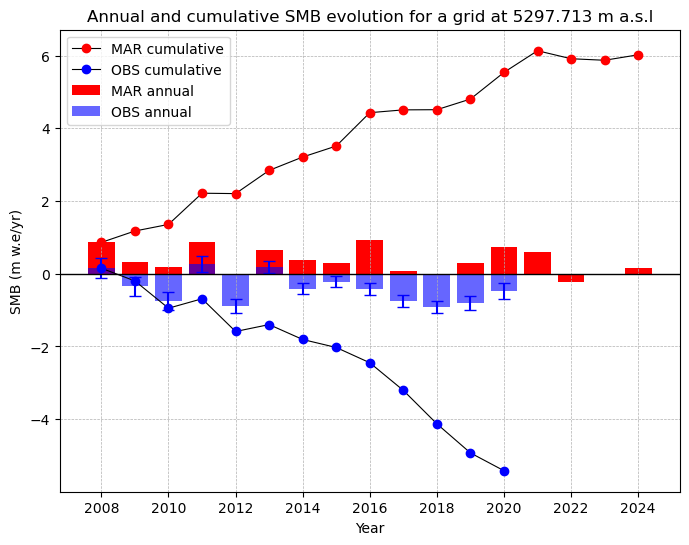

In [49]:
### Série temporelle SMB grille 3 case au nord par rapport au Mera

SMB_list = []
Ygrid, Xgrid = iY+3, iX

for j in range(nyy):
    ###### MAR_data loading and sorting  ######   
    SMB_day = SMB_year[j].sel(TIME=slice(date_ref[j], date_obs[j])).isel(Y=Ygrid, X=Xgrid) # Valeurs du SMB entre les deux dates de mesures (glacioclim)
    SMB_sum = SMB_day.sum(dim='TIME')/1000 # Somme l'entièreté de ces valeurs sur la période, et rapporte les millimètres en mètres
    SMB_MAR = SMB_sum.values
    SMB_list.append(SMB_MAR)

    SH_MAR = ds_SH.isel(y=Ygrid, x=Xgrid) # Altitude de la grille de MAR au Peak Mera (coord iYN,iXN)
    Grid_alt = SH_MAR.values

plt.figure(figsize=(8,6))

SMB_cum = np.cumsum(SMB_list)

plt.bar(years, SMB_list, color="r", alpha=1, width=0.8, label="MAR annual") # SMB MAR annuel sous forme de bar 
plt.plot(years, SMB_cum, color="k", linewidth=0.8, marker="o", markerfacecolor="r", markeredgecolor="r", label="MAR cumulative") # Cumulative SMB

plt.bar(years[:n], annual_MB[:n], yerr=error_annual[:n],
        color="b", alpha=0.6, width=0.8, capsize=4, ecolor="b", label="OBS annual") # SMB OBS annuel sous forme de bar 
plt.plot(years[:n], annual_cum[:n], color="k", linewidth=0.8, marker="o", markerfacecolor="b", markeredgecolor="b", label="OBS cumulative") # Plot jusqu'à ce que la plus petite liste soit vidée

plt.axhline(0, color="k", linewidth=1) # Affiche une ligne à l'horizontal (ici 0)
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(2)) # Force l'espace sur l'axe des x
plt.xlabel("Year")
plt.ylabel("SMB (m w.e/yr)")
plt.title("Annual and cumulative SMB evolution for a grid at "+str(Grid_alt)+" m a.s.l")
plt.legend()
plt.grid(linestyle = '--', linewidth = 0.5)


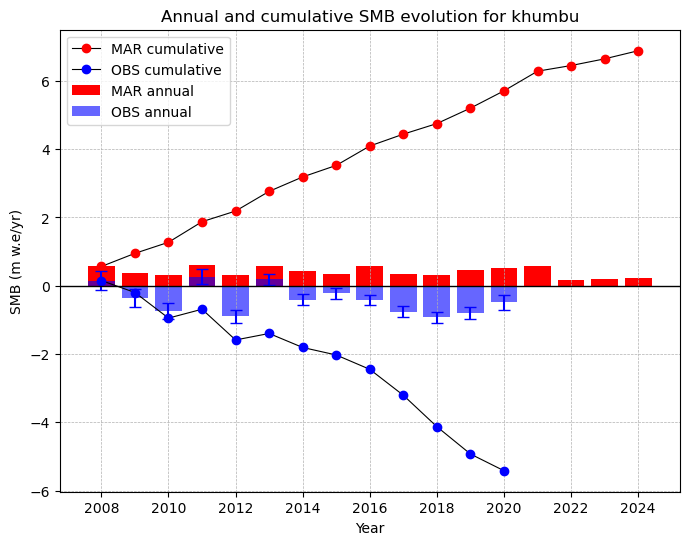

In [50]:
plt.figure(figsize=(8,6))

SMB_cum = np.cumsum(SMB_list_khumbu)

plt.bar(years, SMB_list_khumbu, color="r", alpha=1, width=0.8, label="MAR annual") # SMB MAR annuel sous forme de bar 
plt.plot(years, SMB_cum, color="k", linewidth=0.8, marker="o", markerfacecolor="r", markeredgecolor="r", label="MAR cumulative") # Cumulative SMB

plt.bar(years[:n], annual_MB[:n], yerr=error_annual[:n],
        color="b", alpha=0.6, width=0.8, capsize=4, ecolor="b", label="OBS annual") # SMB OBS annuel sous forme de bar 
plt.plot(years[:n], annual_cum[:n], color="k", linewidth=0.8, marker="o", markerfacecolor="b", markeredgecolor="b", label="OBS cumulative") # Plot jusqu'à ce que la plus petite liste soit vidée

plt.axhline(0, color="k", linewidth=1) # Affiche une ligne à l'horizontal (ici 0)
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(2)) # Force l'espace sur l'axe des x
plt.xlabel("Year")
plt.ylabel("SMB (m w.e/yr)")
plt.title("Annual and cumulative SMB evolution for khumbu")
plt.legend()
plt.grid(linestyle = '--', linewidth = 0.5)

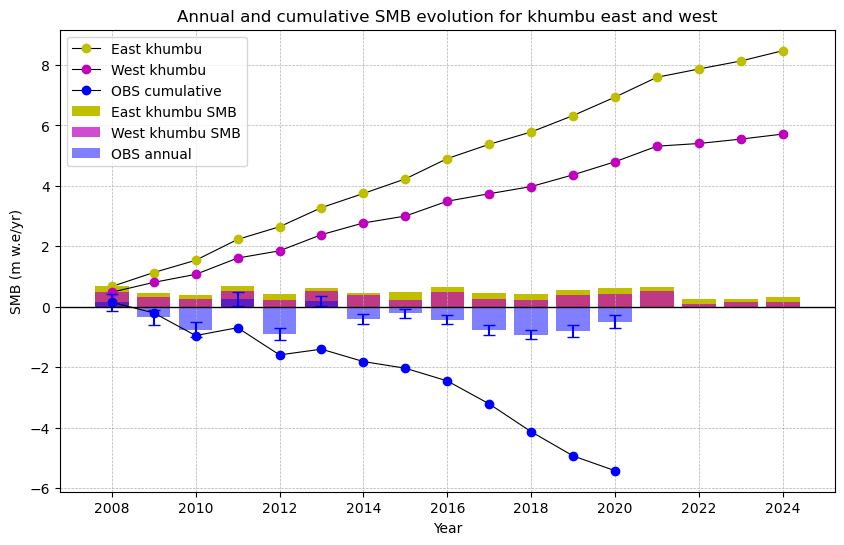

In [51]:
plt.figure(figsize=(10,6))

SMB_cum_east = np.cumsum(SMB_khumbu_east)
SMB_cum_west = np.cumsum(SMB_khumbu_west)

plt.bar(years, SMB_khumbu_east, color="y", alpha=1, width=0.8, label="East khumbu SMB ") # SMB MAR annuel sous forme de bar 
plt.plot(years, SMB_cum_east, color="k", linewidth=0.8, marker="o", markerfacecolor="y", markeredgecolor="y", label="East khumbu") # Cumulative SMB

plt.bar(years, SMB_khumbu_west, color="m", alpha=0.7, width=0.8, label="West khumbu SMB") # SMB MAR annuel sous forme de bar 
plt.plot(years, SMB_cum_west, color="k", linewidth=0.8, marker="o", markerfacecolor="m", markeredgecolor="m", label="West khumbu") # Cumulative SMB

plt.bar(years[:n], annual_MB[:n], yerr=error_annual[:n],
        color="b", alpha=0.5, width=0.8, capsize=4, ecolor="b", label="OBS annual") # SMB OBS annuel sous forme de bar 
plt.plot(years[:n], annual_cum[:n], color="k", linewidth=0.8, marker="o", markerfacecolor="b", markeredgecolor="b", label="OBS cumulative") # Plot jusqu'à ce que la plus petite liste soit vidée

plt.axhline(0, color="k", linewidth=1) # Affiche une ligne à l'horizontal (ici 0)
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(2)) # Force l'espace sur l'axe des x
plt.xlabel("Year")
plt.ylabel("SMB (m w.e/yr)")
plt.title("Annual and cumulative SMB evolution for khumbu east and west")
plt.legend()
plt.grid(linestyle = '--', linewidth = 0.5)

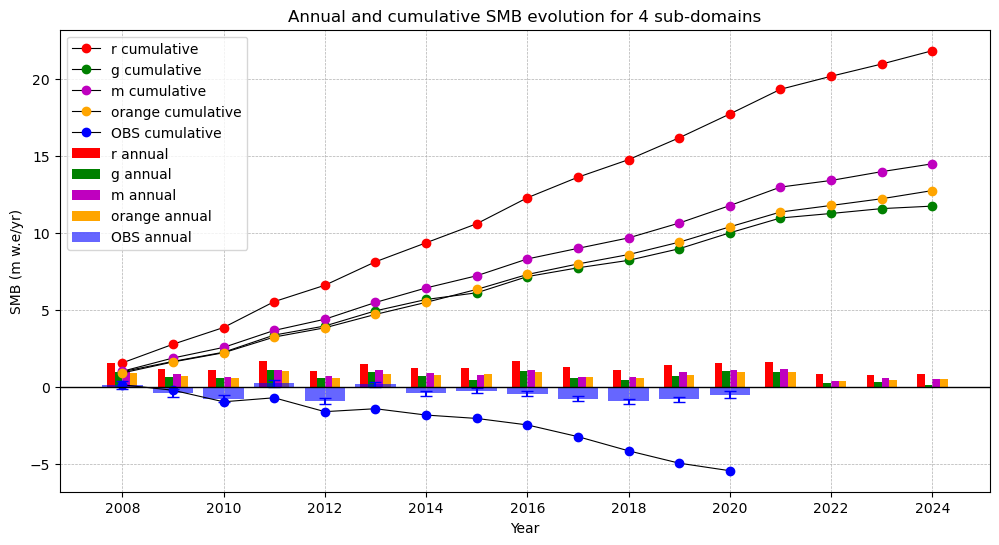

In [52]:
plt.figure(figsize=(12,6))

SMB_cum = {dom: np.cumsum(values) for dom, values in SMB_khumbu.items()} # items() retourne des tuples avec le domaine et la valeur 

colors = ["r", "g", "m", "orange"] # Définition des couleurs pour les sous domaines 

width = 0.15  # Largeur des barres SMB annuel

# Tracé annuel et cumulatif pour chaque sous-domaine
for i, (dom, values) in enumerate(SMB_khumbu.items()): # Enumerate permet ensuite d'utiliser un indice numérique qui boucle sur le sous domaine
    offset = (i - 1.5) * width # Permet de voir les barres légèrement décallés
    
    plt.bar(np.array(years) + offset, values, color=colors[i], alpha=1, width=width, label=f"{dom} annual")
    plt.plot(years, SMB_cum[dom], color="k", linewidth=0.8, marker="o", markerfacecolor=colors[i], markeredgecolor=colors[i], label=f"{dom} cumulative")

##### Observations ######
plt.bar(years[:n], annual_MB[:n], yerr=error_annual[:n],
        color="b", alpha=0.6, width=0.8, capsize=4, ecolor="b", label="OBS annual") # SMB OBS annuel sous forme de bar 
plt.plot(years[:n], annual_cum[:n], color="k", linewidth=0.8, marker="o", markerfacecolor="b", markeredgecolor="b", label="OBS cumulative") # Plot jusqu'à ce que la plus petite liste soit vidée

plt.axhline(0, color="k", linewidth=1) # Affiche une ligne à l'horizontal (ici 0)
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(2)) # Force l'espace sur l'axe des x
plt.xlabel("Year")
plt.ylabel("SMB (m w.e/yr)")
plt.title("Annual and cumulative SMB evolution for 4 sub-domains")
plt.legend()
plt.grid(linestyle = '--', linewidth = 0.5)